In [ ]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import numpy as np
import pandas as pd
import geopandas as gpd
# import tesspy
import shapely
import matplotlib.dates as mdates

import random
import dill
from pathlib import Path
import os


from fame import *
from fame_msa_utils import ShipTracker, ship_propagator, custom_ship_phenomenon_processor, propagate_distribution_from_observations

import h3


In [ ]:
R_earth_km = 6371


## Load satellites

In [ ]:
# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [ ]:
tle_file_name_json = "tles/all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "tles/all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [ ]:
# tle_file_name_txt = "tles/all_tles_20260130.txt"
tle_file_name_txt = "tles/all_tles_20260427.txt"

# min_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
# max_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+ dt.timedelta(seconds=3600*24*2)

lookahead_horizon_h = 36


min_time = dt.datetime.strptime("2026-04-27 00:00:00.00000", "%Y-%m-%d %H:%M:%S.%f").replace(tzinfo=None)
max_time=min_time + dt.timedelta(seconds=3600*lookahead_horizon_h)


In [ ]:
flock_names = []

iceye_names = []

with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("FLOCK"):
            # .strip() removes the trailing newline character (\n)
            flock_names.append(line.strip()) 
            
with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("ICEYE"):
            # .strip() removes the trailing newline character (\n)
            iceye_names.append(line.strip()) 


In [ ]:
print(f"There are {len(flock_names)} Flock sats and {len(iceye_names)} ICEYE sats")

In [ ]:
# planet_satellites = []
# 14-19 decayed

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Ubotica ACCENTURE-1 SUAC": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}
for dove_name in flock_names:
    swaths_at_nadir_km[dove_name] =  16.4 #https://www.newspace.im/constellations/planet-labs

for iceye_name in iceye_names:
    swaths_at_nadir_km[iceye_name] =  100 # Scan imaging, https://sar.iceye.com/5.2.3/productguide/typesofsarcollection/

# print("HACK!")
# for sat, swath in swaths_at_nadir_km.items():
#     if swath<20:
#         swaths_at_nadir_km[sat]*=10

# dove_satellites = [
#     Satellite(dove_name, Orbital(dove_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)
#     for dove_name in flock_names
#     ]

dove_satellites = []

iceye_satellites = [
    Satellite(iceye_name, Orbital(iceye_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True)
    for iceye_name in iceye_names
    ]

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
]
try:
    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN-1 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN-2 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3 300A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4 300B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5 300C", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6 300D", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:

    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]

try:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER-1 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)]
ubotica_satellites = [
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("Ubotica ACCENTURE-1 SUAC", Orbital("ACCENTURE-1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]

mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


In [ ]:
all_satellites = dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+iceye_satellites+loft_satellites+ubotica_satellites+mission_control_satellites

In [ ]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {it: _fov for it in _sat.instruments}

In [ ]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "FLOCK" in sat_name.upper():
        return "midnightblue"
    if "SKYSAT" in sat_name.upper():
        return "midnightblue"
    if "PELICAN" in sat_name.upper():
        return "mediumblue"
    if "TANAGER" in sat_name.upper():
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name.upper():
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name.upper():
        return "darkorange"
    # 
    if "LOFT" in sat_name.upper():
        return "forestgreen"
    #
    if "Ubotica".upper() in sat_name.upper():
        return "lime"
    #
    if "Mission Control".upper() in sat_name.upper():
        return "orchid"
    #
    if "ICEYE" in sat_name.upper():
        return "darkturquoise"
    #
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name.upper():
        return "blue"
    # Black
    if "UMBRA" in constellation_name.upper():
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name.upper():
        return "darkorange"
    # 
    if "LOFT" in constellation_name.upper():
        return "forestgreen"
    #
    if "Ubotica".upper() in constellation_name.upper():
        return "lime"
    #
    if "Mission Control".upper() in constellation_name.upper():
        return "orchid"
    if "ICEYE" in constellation_name.upper():
        return "darkturquoise"
    return "red"

def satmarkerer(sat_name):
    if "FLOCK" in sat_name.upper():
        return "p"
    if "SKYSAT" in sat_name.upper():
        return "p"
    if "PELICAN" in sat_name.upper():
        return "p"
    if "TANAGER" in sat_name.upper():
        return "p"
    # Black
    if "UMBRA" in sat_name.upper():
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name.upper():
        return "D"
    # 
    if "LOFT" in sat_name.upper():
        return "p"
    #
    if "Ubotica".upper() in sat_name.upper():
        return "p"
    #
    if "Mission Control".upper() in sat_name.upper():
        return "p"
    #
    if "ICEYE" in sat_name.upper():
        return "D"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}



# Volcanoes

In [ ]:
# Read the volcano list (.xls file)
volcano_df = pd.read_excel('data/GVP_Volcano_List_Holocene_202606021456.xlsx', header=1)

# Read the eruption list (.xlsx file)
eruption_df = pd.read_excel('data/GVP_Eruption_List_Holocene_20260424.xlsx', sheet_name="Eruption List", header=1)

# # Display basic info
# print("Volcano List shape:", volcano_df.shape)
# print("Eruption List shape:", eruption_df.shape)
# print("\nVolcano List columns:", volcano_df.columns.tolist())
# print("\nEruption List columns:", eruption_df.columns.tolist())

In [ ]:
eruptions = eruption_df.merge(volcano_df,on='Volcano Name', how='left')

In [ ]:
class Eruption(Phenomenon):
    def __init__(
            self,
            lon_deg: float,
            lat_deg: float,
            alt_km: float,
            start_time: dt.datetime,
            end_time: dt.datetime,
            VEI: float=0,
            name: str=""):
        super().__init__(
            lon_deg=lon_deg,
            lat_deg=lat_deg,
            alt_km=alt_km,
            heading_deg=None,
            speed_kph=None,
            start_time=start_time,
            end_time=end_time,
            name=name
            )
        self.VEI = VEI

volcanic_eruptions = []

for ix, row in eruptions.iterrows():
    start_year = row['Start Year'] 
    if np.isnan(start_year):
        continue
    if start_year<0: # Upsetting, but dt does not support BCE dates!
        continue
    start_month = row['Start Month'] 
    if np.isnan(start_month) or start_month==0:
        start_month=6
    start_day = row['Start Day'] 
    if np.isnan(start_day) or start_day==0:
        start_day = 15
    end_year = row['End Year'] 
    if np.isnan(end_year):
        continue
    if end_year<0: # Upsetting, but dt does not support BCE dates!
        continue
    end_month = row['End Month'] 
    if np.isnan(end_month) or end_month==0:
        end_month=6
    end_day = row['End Day'] 
    if np.isnan(end_day) or end_day==0:
        end_day = 15

    try:
        vstart_time=dt.datetime(int(start_year), int(start_month), int(start_day))
        vend_time=dt.datetime(int(end_year), int(end_month), int(end_day))
    except ValueError as e:
        import pdb; pdb.set_trace()

    volcanic_eruptions.append(
        Eruption(
            lon_deg=row['Longitude'],
            lat_deg=row['Latitude'],
            alt_km=float(row['Elevation (m)'])/1e3,
            name=row['Volcano Name'],
            start_time=vstart_time,
            end_time=vend_time,
            VEI=row['VEI']
            )
    )



In [ ]:
volcano_locations = [
    Location(
        lon_deg=row['Longitude'],
        lat_deg=row['Latitude'],
        alt_km=float(row['Elevation (m)'])/1e3,
        name=row['Volcano Name'],
        )
        for ix, row in eruptions.iterrows() if row['VEI']>4 and row['Start Year']>1900
]

In [ ]:
volcano_locations = list(set(volcano_locations))
print(len(volcano_locations))

In [ ]:
figglobal = plt.figure(figsize=(20,10))
ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
for volcano in volcanic_eruptions:
    ax.plot(
        volcano.lon_deg,
        volcano.lat_deg,
        'D',
        transform=ccrs.PlateCarree(),
        color='m',
        markersize=1*volcano.VEI,
        alpha=max(0., 1-(dt.datetime.now()-volcano.end_time)/dt.timedelta(days=365*dt.datetime.now().year))
        )


### Communication opportunities

In [ ]:
ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

### Add an active eruption now

In [ ]:
volcanic_eruptions

In [ ]:
first_eruption = volcanic_eruptions[0]

volcanic_eruptions.append(
    Eruption(
        lon_deg=first_eruption.lon_deg,
        lat_deg=first_eruption.lat_deg,
        alt_km=first_eruption.alt_km,
        name=first_eruption.name,
        start_time=min_time,
        end_time=max_time,
        VEI=first_eruption.VEI,
        )
)

## Initialize the world, the constellations, and the brokers

In [ ]:
# phenomena = []

world_with_brokers = World(satellites = all_satellites, phenomena=volcanic_eruptions)

scheduler_planet = ConstellationGroundScheduler(satellites=dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Planet")
scheduler_umbra = ConstellationGroundScheduler(satellites=umbra_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Umbra")
scheduler_capella = ConstellationGroundScheduler(satellites=capella_acadia_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Capella")
scheduler_LOFT = ConstellationGroundScheduler(satellites=loft_satellites, ground_stations=ground_stations, world=world_with_brokers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=ubotica_satellites, ground_stations=ground_stations, world=world_with_brokers, name="UBOTICA")
scheduler_mission_control = ConstellationGroundScheduler(satellites=mission_control_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Mission Control")
scheduler_aerospace = ConstellationGroundScheduler(satellites=aerospace_corp_satellites, ground_stations=ground_stations, world=world_with_brokers, name="AC")
scheduler_iceye = ConstellationGroundScheduler(satellites=iceye_satellites, ground_stations=ground_stations, world=world_with_brokers, name="ICEYE")

all_constellations = [scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace, scheduler_iceye]

constcolors = {c.name: constcolorer(c.name) for c in all_constellations}


world_with_brokers.add_constellation(scheduler_planet)
world_with_brokers.add_constellation(scheduler_umbra)
world_with_brokers.add_constellation(scheduler_capella)
world_with_brokers.add_constellation(scheduler_LOFT)
world_with_brokers.add_constellation(scheduler_ubotica)
world_with_brokers.add_constellation(scheduler_mission_control)
world_with_brokers.add_constellation(scheduler_aerospace)
world_with_brokers.add_constellation(scheduler_iceye)

broker = Broker(constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace], world=world_with_brokers, name="Broker 1")


world_with_brokers.add_broker(broker)

world_with_brokers.time = min_time

We start with some static functions we will use to compute rewards

In [ ]:
def rewarder_observation(opportunity: ObservationOpportunity, preferred_zenith_angle_deg=45):

    static_reward = 50
    
    look_angle_reward = abs(90.-opportunity.look_angle_dec_deg)/90.
    
    zenith_angle_reward = abs(preferred_zenith_angle_deg-opportunity.sun_zenith_angle_deg)/90
    
    # if the Sun is below the horizon
    # if abs(opportunity.sun_zenith_angle_deg)>90 and opportunity.instrument == InstrumentType.RGB:
    #     zenith_angle_reward = -100

    range_reward = 1/(opportunity.range_km/1000)

    return look_angle_reward+zenith_angle_reward+range_reward+static_reward

def rewarder_search(opportunity: ObservationOpportunity, preferred_zenith_angle_deg=45):

    static_reward = 0
    look_angle_reward = abs(90.-opportunity.look_angle_dec_deg)/90.
    zenith_angle_reward = 0
    range_reward = 1/(opportunity.range_km/1000)
    return look_angle_reward+zenith_angle_reward+range_reward+static_reward

def success_declarer(data_product):
    return len(data_product)>0

In [ ]:

def timeline_updater_volcanos(
        current_time: dt.datetime,
        requests: list[ConstrainedObservationRequest],
        timelines: list[Timeline],
        max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800),
        verbose=True
        ):
    # Go through the requests
    # If we saw a given volcano active, mark it as active at a given time
    # Q: how do we know which volcano a request is for? The volcano is
    #  - In the name (with an ugly suffix)
    #  - In the lon lat (but we will move it )
    #  - In the plotting group
    # Then reset the timelines to "the volcano was active at this time in the past"
    # So keep a dict with volcano->last_seen_time
    # If there isn't a reading, then we mark it as inactive now

    volcano_last_seen_active = {t.name: min_time for t in timelines}
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                volcano_observed = current_request.request_group
                volcano_last_seen_active[volcano_observed] = max(volcano_last_seen_active[volcano_observed], current_request.observation_opportunity.time)
    
    for timeline in timelines:
        last_seen_time = volcano_last_seen_active[timeline.name]
        tl_measured_value = 0
        if last_seen_time > min_time:
            tl_measured_value = 1
        _current_estimated_value, _current_estimated_rate = timeline._get_value_and_rate_at(last_seen_time, print_debug=False)
        timeline.reset_timeline(last_seen_time, tl_measured_value, _current_estimated_rate)
    
        if verbose:
            print(f"    [Dispatcher] Resetting timeline {timeline.name} to {tl_measured_value} (est rate {_current_estimated_rate}) at time {last_seen_time}")
    return timelines

# def request_updater_msa(
#         current_time: dt.datetime,
#         requests: list[ConstrainedObservationRequest],
#         timelines: list[Timeline]=[],
#         verbose=True,
#         initial_toi_pose: Pose=initial_toi_pose_rotterdam,
#         search_name_str: str="",
#         samples_propagation=200,
#         propagate_negative_samples: bool=True,
#         plot_filter_distribution: bool=False,
#         plot_axis: plt.axis = None,
#         save_filter_distribution: bool=False,
#         save_name: str=None,
#         ):
#     # ShipTracker ingests measurements via update_location and propagates said locations via propagate_locations.
#     # Workflow:
#     # Look for the latest observation in completed requests.
    
#     initial_ship_location = Pose(time=min_time, lon_deg=initial_toi_pose.lon_deg, lat_deg=initial_toi_pose.lat_deg, alt_km=initial_toi_pose.alt_km, heading_deg=initial_toi_pose.heading_deg, speed_kph=initial_toi_pose.speed_kph)

#     # Order unfilled requests by min_time.
#     unfilled_requests = [r for r in requests if r.completed == False and r.dispatched == False and r.feasible == True and r.observation_request.max_time>current_time]
#     # print(f"Unfilled requests ({len(unfilled_requests)}): {unfilled_requests}")
#     unfilled_requests_dict_by_time = {}
#     for ur in unfilled_requests:
#         urtime = ur.observation_request.min_time+(ur.observation_request.max_time-ur.observation_request.min_time)/2
#         if urtime not in unfilled_requests_dict_by_time.keys():
#             unfilled_requests_dict_by_time[urtime] = []
#         unfilled_requests_dict_by_time[urtime].append(ur)

#     pose_propagator=lambda _previous_pose, _deltat: ship_propagator(
#         previous_pose=_previous_pose,
#         deltat=_deltat,
#         heading_variance=heading_variance,
#         speed_variance=speed_variance,
#         max_speed_if_unspecified_kph=avg_speed_kph,
#         )

#     hexes_by_time = propagate_distribution_from_observations(
#         query_times=list(unfilled_requests_dict_by_time.keys()),
#         initial_pose=initial_ship_location,
#         observation_requests=requests,
#         pose_propagator=pose_propagator,
#         target_name=search_name_str,
#         h3_resolution=5, # Res 5: 9.85 km side. Res 6: 3.72 km side
#         samples_propagation=samples_propagation,
#         propagate_negative_samples=propagate_negative_samples,
#         verbose=verbose,
#         plot_filter_distribution=plot_filter_distribution,
#         )

#     # def found_ship_in_data_product(data_product: list[Phenomenon], search_name: str):
#     #     found_request = False
#     #     for ship_location_phenomenon in data_product:
#     #         # If the ship is the right one
#     #         if ((len(search_name)==0) or (search_name in ship_location_phenomenon.name)):
#     #             found_request = True
#     #             ship_location = custom_ship_phenomenon_processor(
#     #                 observation=completed_request.observation_opportunity,
#     #                 spacecraft=completed_request.observation_opportunity.satellite,
#     #                 phenomenon=ship_location_phenomenon
#     #                 )
#     #             return ship_location
#     #     return False

#     for unfulfilled_time in unfilled_requests_dict_by_time.keys():
#         points_hex_tessellation = hexes_by_time[unfulfilled_time]
#         for unfulfilled_request_ix, unfulfilled_request in enumerate(unfilled_requests_dict_by_time[unfulfilled_time]):
#             if unfulfilled_request_ix>len(points_hex_tessellation)-1:
#                 # We have run out of hexagons. Which is good! We should remove this request and the following ones. This is a very very hacky way of doing it.
#                 # The proper way is to pop the request from the list AND THE GRAPH
#                 unfulfilled_request.scheduled = True
#                 unfulfilled_request.dispatched = True
#                 unfulfilled_request.completed = True
#                 unfulfilled_request.feasible = False
#                 unfulfilled_request.successful_execution = False
#                 continue
#             else:
#                 hex_centroid = points_hex_tessellation.iloc[unfulfilled_request_ix].geometry.centroid
#                 _updated_request = ObservationRequest(
#                     lat_deg=hex_centroid.y,
#                     lon_deg=hex_centroid.x,
#                     min_time=unfulfilled_request.observation_request.min_time,
#                     max_time = unfulfilled_request.observation_request.max_time,
#                     alt_km=unfulfilled_request.observation_request.alt_km,
#                     instrument=unfulfilled_request.observation_request.instrument,
#                     request_name=unfulfilled_request.observation_request.name,
#                     min_elevation_deg=unfulfilled_request.observation_request.min_elevation_deg,
#                 )
#                 unfulfilled_request.observation_request = _updated_request
#         # fi

#     return requests



### Create the workflow proper

In [ ]:
# Workflow:
# Mandatory: check each volcano at least once
# If the check succeeds, continue imaging every few hours until the signal fades.
# Implementation: time windows + wait_if_feasible on previous tasks + a timeline for "is the volcano active".


observations_volcanoes = [
    ObservationRequest(volcano.lon_deg, volcano.lat_deg, min_time=min_time, max_time=min_time+dt.timedelta(seconds=3600*6), alt_km=volcano.alt_km, request_name=volcano.name, instrument=InstrumentType.RGB)
    for volcano in volcano_locations
]

follow_up_interval_h = 3

constrained_requests_volcanoes = []

are_volcanoes_active_timelines = {
    volcano: Timeline(name=volcano.name, initial_time=min_time, initial_value=1, initial_rate=-1./(3600*24), min_value=-30, max_value=30)
    for volcano in observations_volcanoes
    }


for volcano in observations_volcanoes:

    constrained_requests_by_volcano = []

    search_request = ConstrainedObservationRequest(
        name = volcano.name,
        observation_request=volcano,
        is_mandatory=True,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
        timeline_constraints=[],
        timeline_impacts=[TaskTimelineImpact(timeline=are_volcanoes_active_timelines[volcano], time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
        rewarder=rewarder_observation,
        success_declarer=success_declarer,
        request_group=volcano.name,
    )

    constrained_requests_by_volcano.append(search_request)

    for follow_up_ix in range(0,lookahead_horizon_h,follow_up_interval_h):
        follow_up_obs_request = ObservationRequest(volcano.lon_deg, volcano.lat_deg, min_time=min_time, max_time=max_time, alt_km=volcano.alt_km, request_name=volcano.name+f"_followup_{follow_up_ix}", instrument=InstrumentType.RGB)
        
        obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, search_request, {'offset': dt.timedelta(seconds=3600*follow_up_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, search_request, {'offset': dt.timedelta(seconds=3600*(follow_up_ix+follow_up_interval_h))}),
        ]

        for existing_request in constrained_requests_by_volcano:
            obs_task_constraints.append(
                Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
            )

        follow_up_constrained_request = ConstrainedObservationRequest(
            name = follow_up_obs_request.name,
            observation_request=follow_up_obs_request,
            is_mandatory=False,
            schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
            dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
            task_constraints = obs_task_constraints,
            timeline_constraints=[TaskTimelineConstraint(timeline=are_volcanoes_active_timelines[volcano], time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0.1),],
            timeline_impacts=[],
            rewarder=rewarder_observation,
            success_declarer=success_declarer,
            request_group=volcano.name,
        )

        constrained_requests_by_volcano.append(follow_up_constrained_request)
    
    constrained_requests_volcanoes.extend(constrained_requests_by_volcano)

workflow_volcanoes = Workflow(
    constrained_observation_requests=constrained_requests_volcanoes,
    timelines=list(are_volcanoes_active_timelines.values()),
    timeline_updater=timeline_updater_volcanos,
    )

broker.add_workflow(workflow_volcanoes)

# Idea: if there is an eruption, follow up every x hours. 


## Add brokers that are mostly interested in cities

In [ ]:
num_cities_to_observe = 25

broker_cities_asia = Broker(
    constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace],
    world=world_with_brokers,
    name="Cities broker (Asia)"
)

broker_cities_america = Broker(
    constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace],
    world=world_with_brokers,
    name="Cities broker (America)"
)

world_with_brokers.add_broker(broker_cities_asia)
world_with_brokers.add_broker(broker_cities_america)

cities_of_the_world = pd.read_csv("simplemaps_worldcities_basicv1.901/worldcities.csv")

cities_of_asia_and_thereabouts_mask = cities_of_the_world.apply(lambda c: (c.lng<-170 or c.lng>26) and (c.lat>-11), axis=1)
cities_of_the_americas_and_thereabouts_mask = cities_of_the_world.apply(lambda c: (c.lng>-170 and c.lng<-30), axis=1)

cities_of_asia_and_thereabouts = cities_of_the_world[cities_of_asia_and_thereabouts_mask]
cities_of_the_americas_and_thereabouts = cities_of_the_world[cities_of_the_americas_and_thereabouts_mask]



sampled_cities_of_asia = cities_of_asia_and_thereabouts.sample(n=num_cities_to_observe,weights='population',axis=0, random_state=0)
sampled_cities_of_americas = cities_of_the_americas_and_thereabouts.sample(n=num_cities_to_observe,weights='population',axis=0, random_state=0)

sampled_observations_asia = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_cities_of_asia.iterrows()
]

sampled_observations_americas = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_cities_of_americas.iterrows()
]

cities_constrained_requests_asia = [
    ConstrainedObservationRequest(
        name = city.name,
        observation_request=city,
        is_mandatory=False,
        timeline_constraints=[],
        timeline_impacts=[],
        rewarder=rewarder_observation,
    ) for city in sampled_observations_asia
]

cities_constrained_requests_americas = [
    ConstrainedObservationRequest(
        name = city.name,
        observation_request=city,
        is_mandatory=False,
        timeline_constraints=[],
        timeline_impacts=[],
        rewarder=rewarder_observation,
    ) for city in sampled_observations_americas
]

cities_workflow_asia = Workflow(
    constrained_observation_requests=cities_constrained_requests_asia,
    timelines=[]    
    )

cities_workflow_america = Workflow(
    constrained_observation_requests=cities_constrained_requests_americas,
    timelines=[]    
    )

broker_cities_asia.add_workflow(cities_workflow_asia)
broker_cities_america.add_workflow(cities_workflow_america)



#### Set up plotting

In [ ]:
# Plot the timelines

num_requests = max([len(b.workflow.constrained_observation_requests) for b in world_with_brokers.brokers if b.workflow is not None])
num_timelines = max([len(b.workflow.timelines) for b in world_with_brokers.brokers if b.workflow is not None])

height_ratios = [num_requests]
height_ratios.extend([1,]*num_timelines)

fig, baxes = plt.subplots(
    num_timelines+1,
    len(world_with_brokers.brokers),
    sharex=True,
    height_ratios=height_ratios,
    figsize=(12*len(world_with_brokers.brokers), int(math.ceil(.2*num_requests+num_timelines))),
    layout="constrained"
    )

broker_axes = {}
if len(world_with_brokers.brokers)>1:
    for broker_ix, _broker in enumerate(world_with_brokers.brokers):
        if num_timelines>0:
            broker_axes[_broker] = baxes[:, broker_ix]
        else:
            broker_axes[_broker] = baxes[broker_ix]
else:
    broker_axes[world_with_brokers.brokers[0]] = baxes

## Start the workflows!

In [ ]:
broker.schedule_workflow(
    current_time=world_with_brokers.time,
    use_ilp=False,
    plot_schedule=True,
    # plot_axes=broker_axes[broker],
    update_timelines=False, # Only the first time
    update_requests=False, # Only the first time
    plot_night_in_schedule=False,
    # plot_location_for_night_in_schedule=Rotterdam,
    save_schedule_plot=True,
    max_solver_time_s=300
)

In [ ]:
# broker_cities_asia.schedule_workflow(
#     current_time=world_with_brokers.time,
#     use_ilp=False,
#     plot_schedule=False,
#     # plot_axes=broker_axes[broker],
#     update_timelines=False, # Only the first time
#     update_requests=False, # Only the first time
#     plot_night_in_schedule=True,
#     # plot_location_for_night_in_schedule=Rotterdam,
#     save_schedule_plot=True,
#     max_solver_time_s=300
# )

In [ ]:
# broker_cities_america.schedule_workflow(
#     current_time=world_with_brokers.time,
#     use_ilp=False,
#     plot_schedule=False,
#     # plot_axes=broker_axes[broker],
#     update_timelines=False, # Only the first time
#     update_requests=False, # Only the first time
#     plot_night_in_schedule=True,
#     # plot_location_for_night_in_schedule=Rotterdam,
#     save_schedule_plot=True,
#     max_solver_time_s=300
# )

     [Dispatcher] Request Azul, Cerro_followup_0 not dispatchable: constraint {'edge_type': <class 'fame_workflow.TaskTimelineConstraint'>, 'constraint_time': <TaskImpactTime.PRE: 0>, 'constraint_type': <TimelineConstraintType.GREATER_OR_EQUAL: 0>, 'constraint_value': 0.1} on timeline Timeline Azul, Cerro with 2 impacts at 2026-04-27 05:16:30.853315 violated (timeline value is -0.21980154299768517)
     [Dispatcher] We marked some tasks as infeasible. Rerunning the dispatcher
     [Dispatcher] Request Azul, Cerro_followup_3 not dispatchable: constraint {'edge_type': <class 'fame_workflow.TaskTimelineConstraint'>, 'constraint_time': <TaskImpactTime.PRE: 0>, 'constraint_type': <TimelineConstraintType.GREATER_OR_EQUAL: 0>, 'constraint_value': 0.1} on timeline Timeline Azul, Cerro with 2 impacts at 2026-04-27 08:27:58.799135 violated (timeline value is -0.3527638788773148)
     [Dispatcher] We marked some tasks as infeasible. Rerunning the dispatcher
     [Dispatcher] Request Azul, Cerro_f

/Users/frossi/Documents/JPL/FAME AIST/code/fame_workflow.py:1267: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(num_timelines+1,1, sharex=True, height_ratios=height_ratios, figsize=(12, int(math.ceil(.2*num_request_groups+num_timelines))))


     [Dispatcher] Request Azul, Cerro_followup_21 not dispatchable: constraint {'edge_type': <class 'fame_workflow.TaskTimelineConstraint'>, 'constraint_time': <TaskImpactTime.PRE: 0>, 'constraint_type': <TimelineConstraintType.GREATER_OR_EQUAL: 0>, 'constraint_value': 0.1} on timeline Timeline Azul, Cerro with 2 impacts at 2026-04-28 01:31:10.531342 violated (timeline value is -1.0633163349768517)
     [Dispatcher] We marked some tasks as infeasible. Rerunning the dispatcher
     [Dispatcher] Request Azul, Cerro_followup_24 not dispatchable: constraint {'edge_type': <class 'fame_workflow.TaskTimelineConstraint'>, 'constraint_time': <TaskImpactTime.PRE: 0>, 'constraint_type': <TimelineConstraintType.GREATER_OR_EQUAL: 0>, 'constraint_value': 0.1} on timeline Timeline Azul, Cerro with 2 impacts at 2026-04-28 05:28:29.410762 violated (timeline value is -1.2281181801157406)
     [Dispatcher] We marked some tasks as infeasible. Rerunning the dispatcher
     [Dispatcher] Request Azul, Cerro_

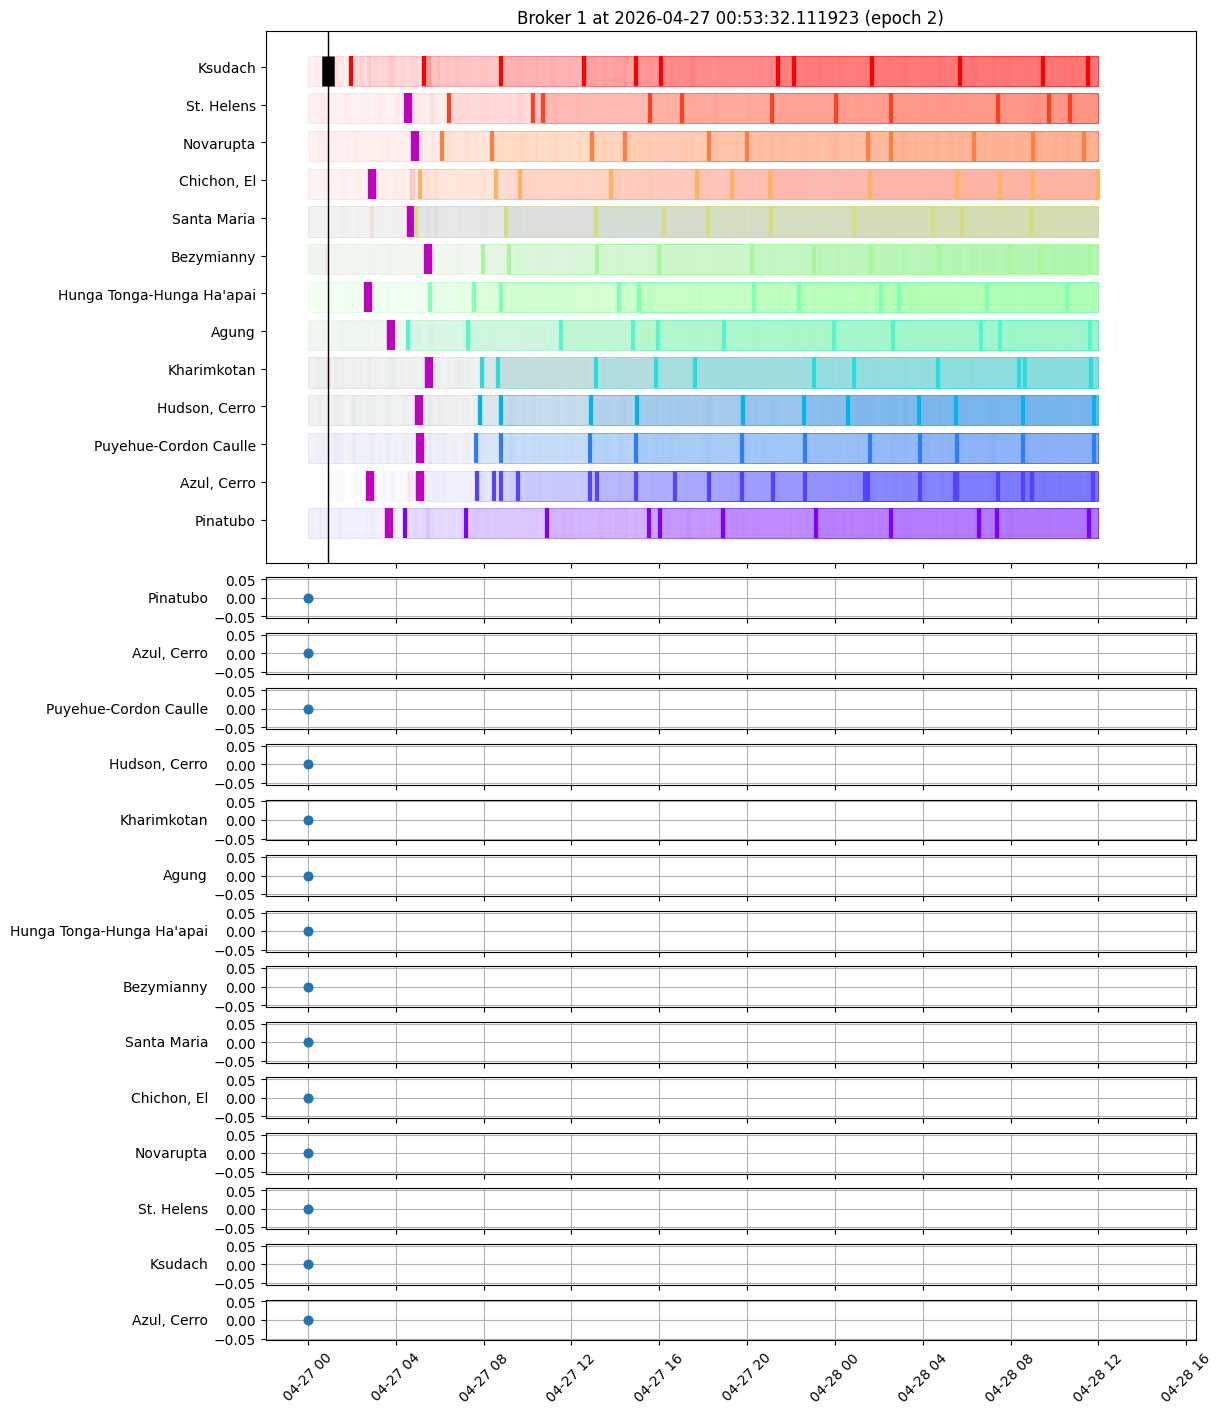

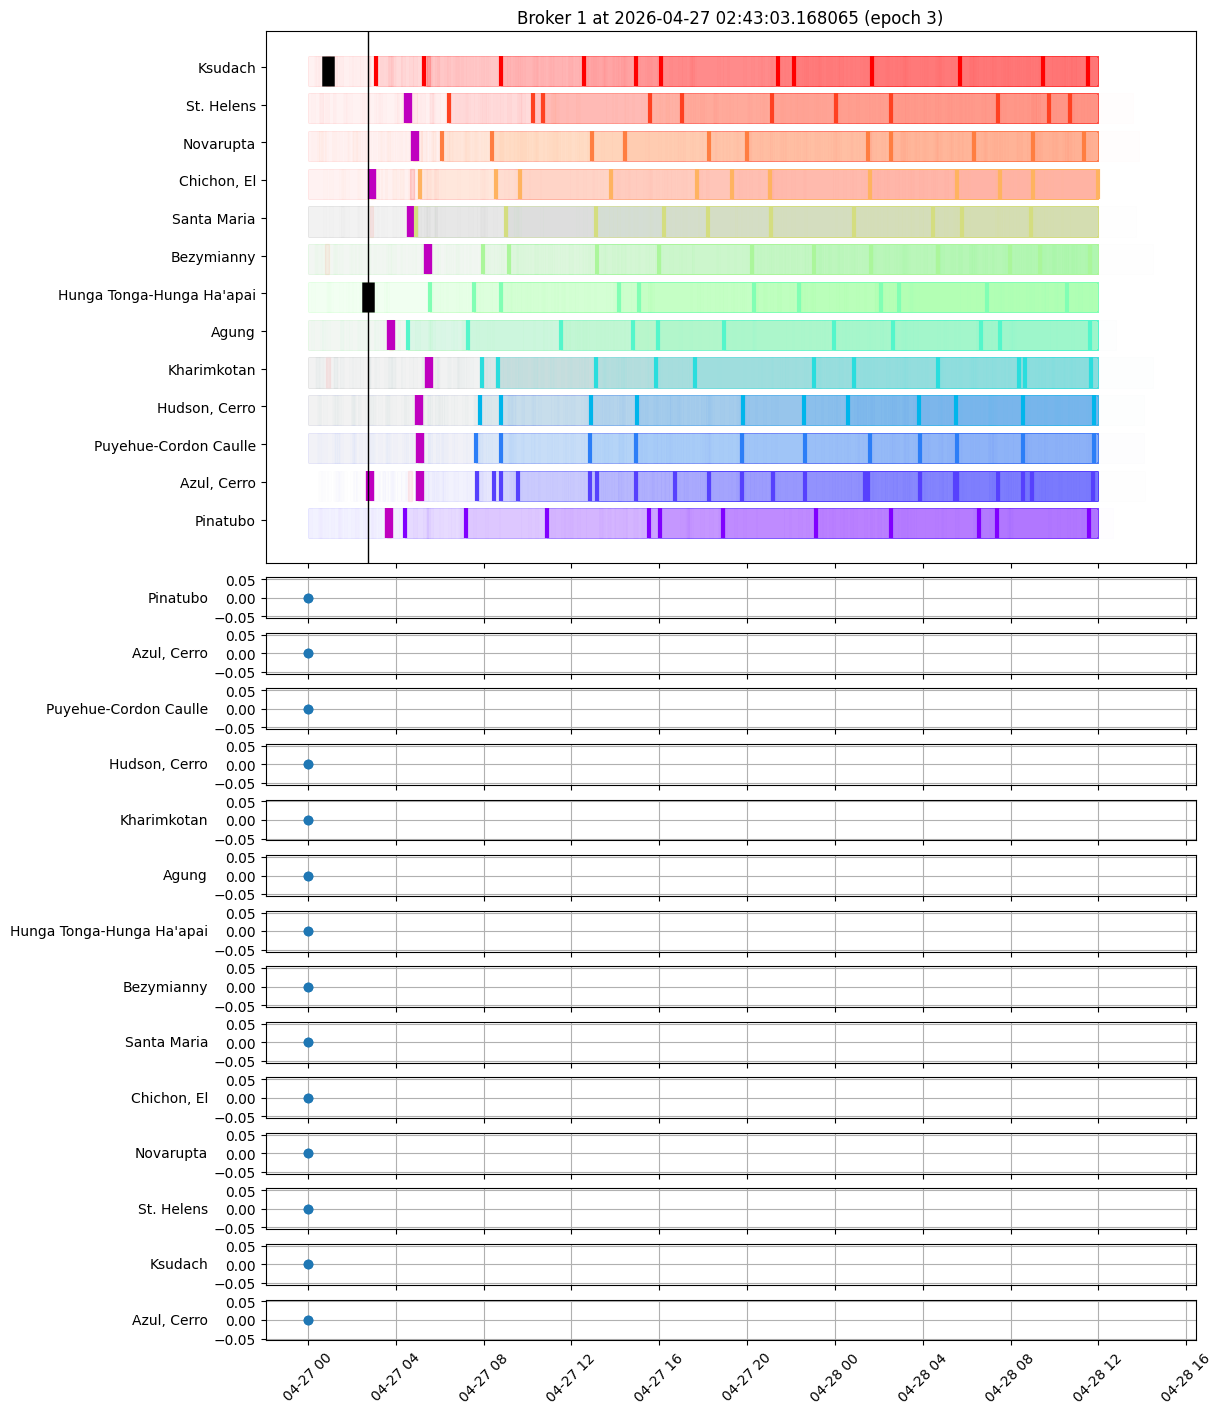

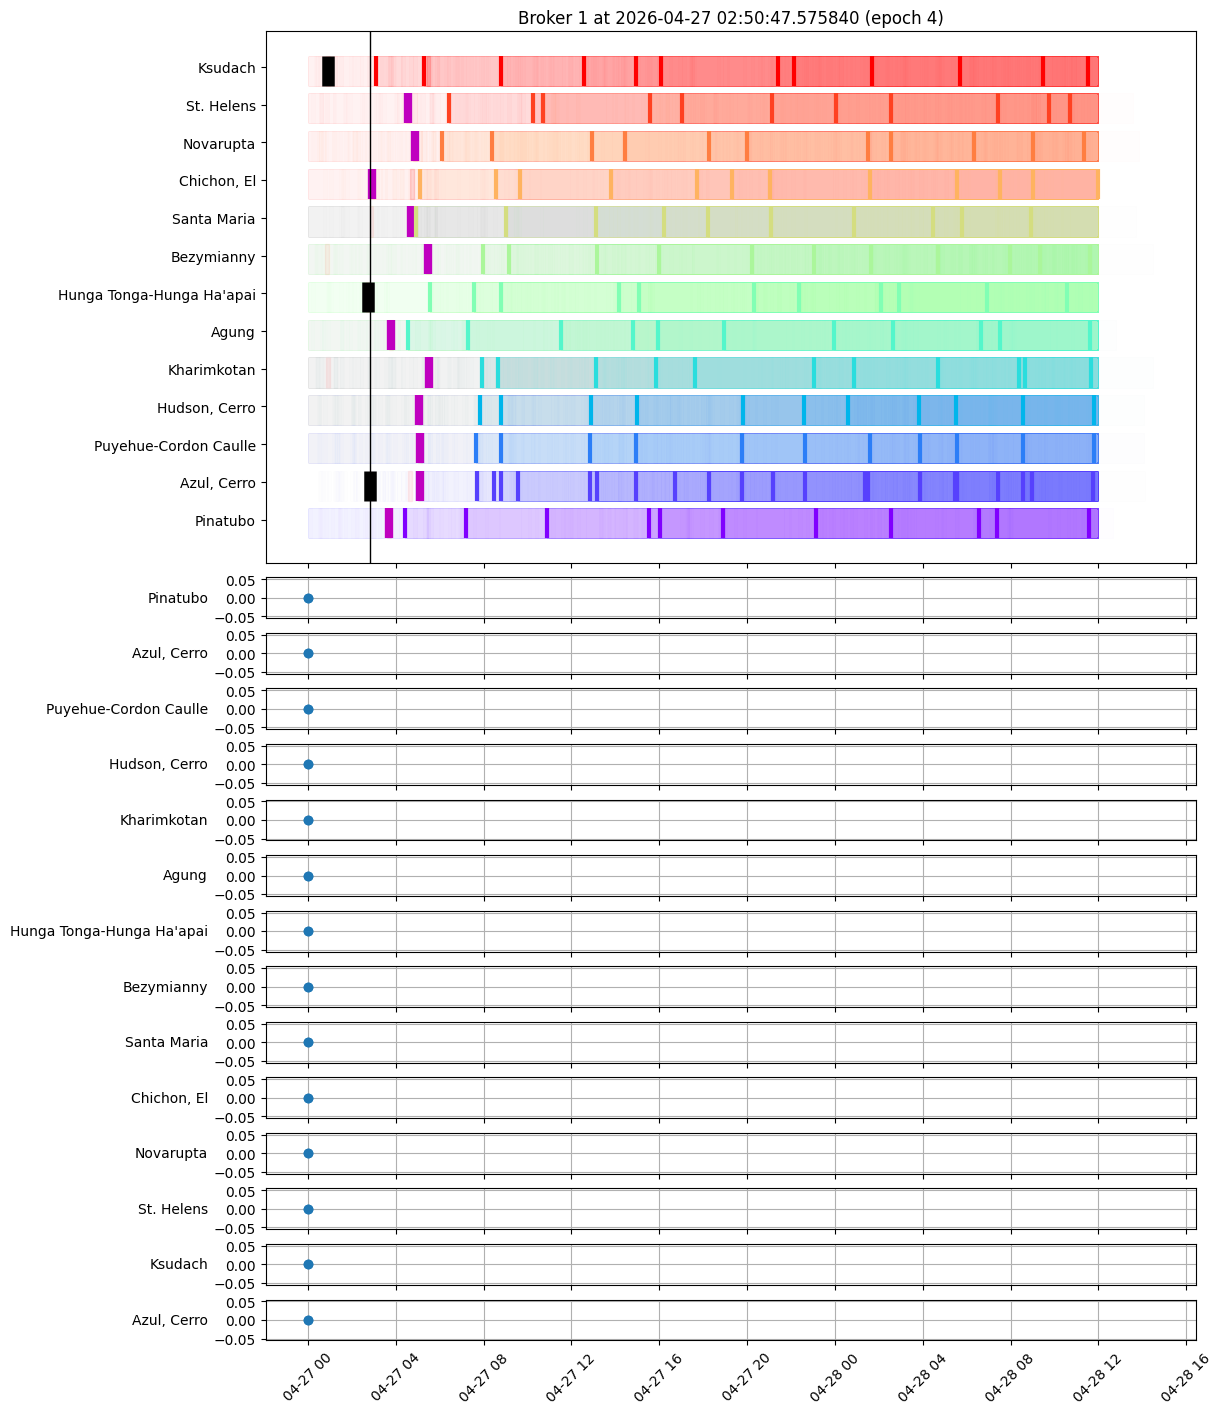

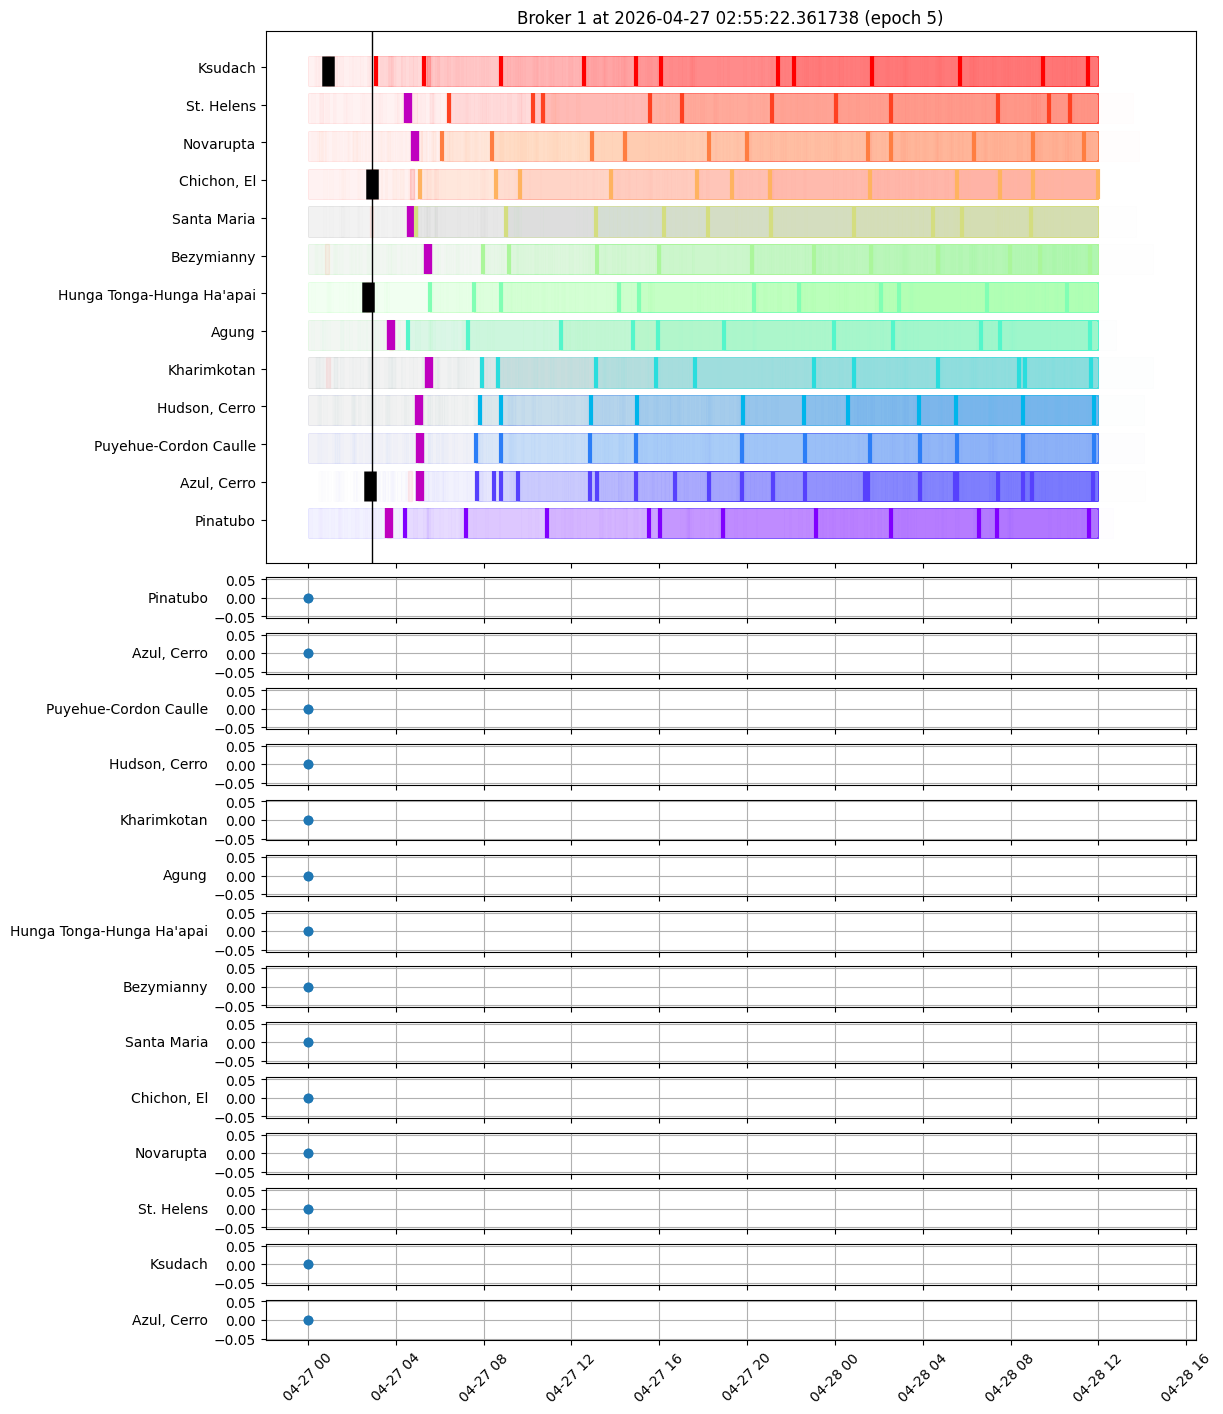

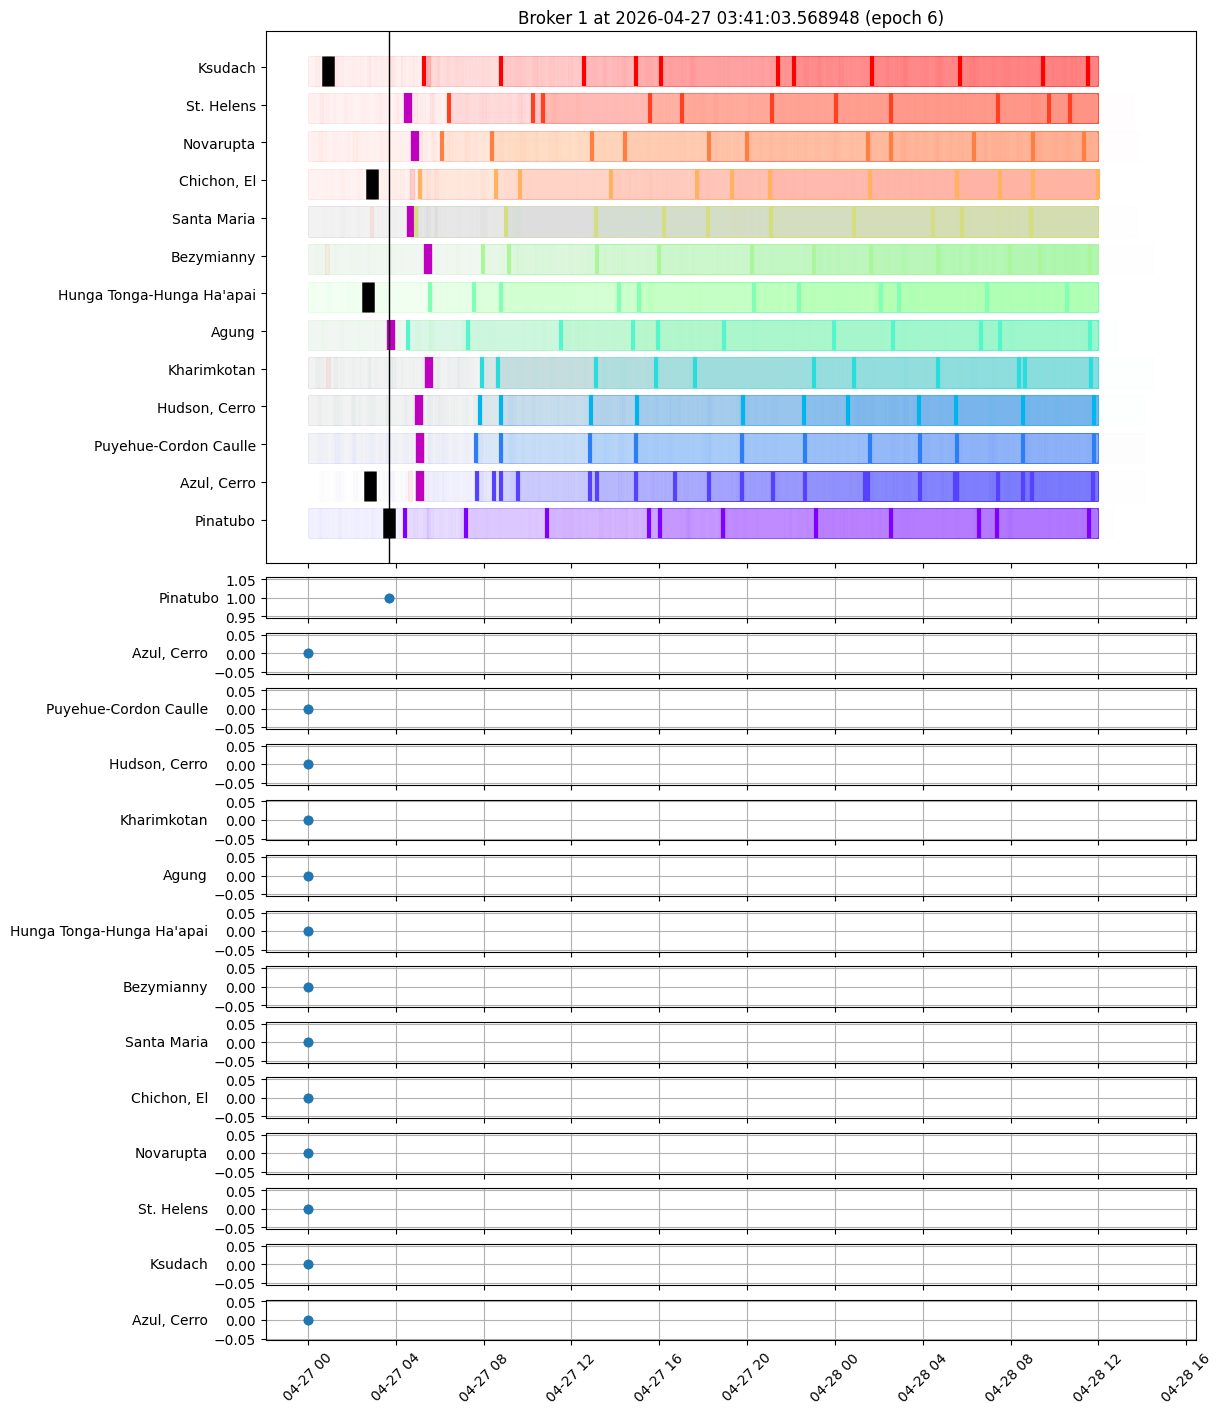

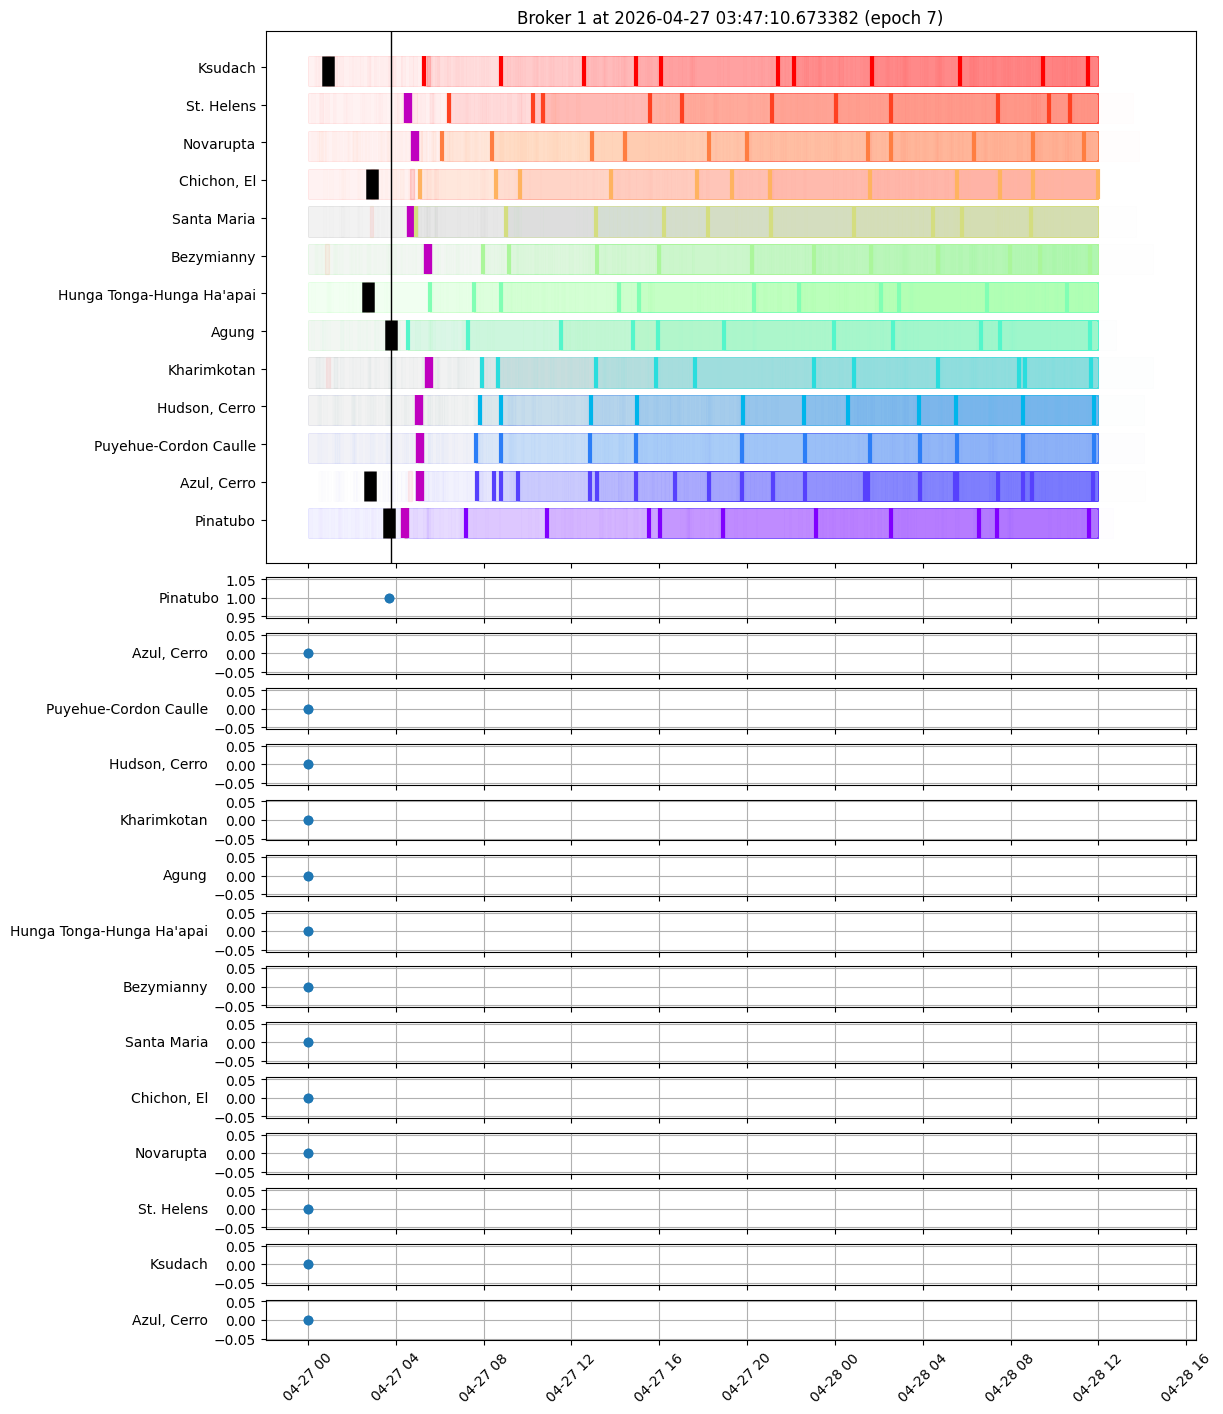

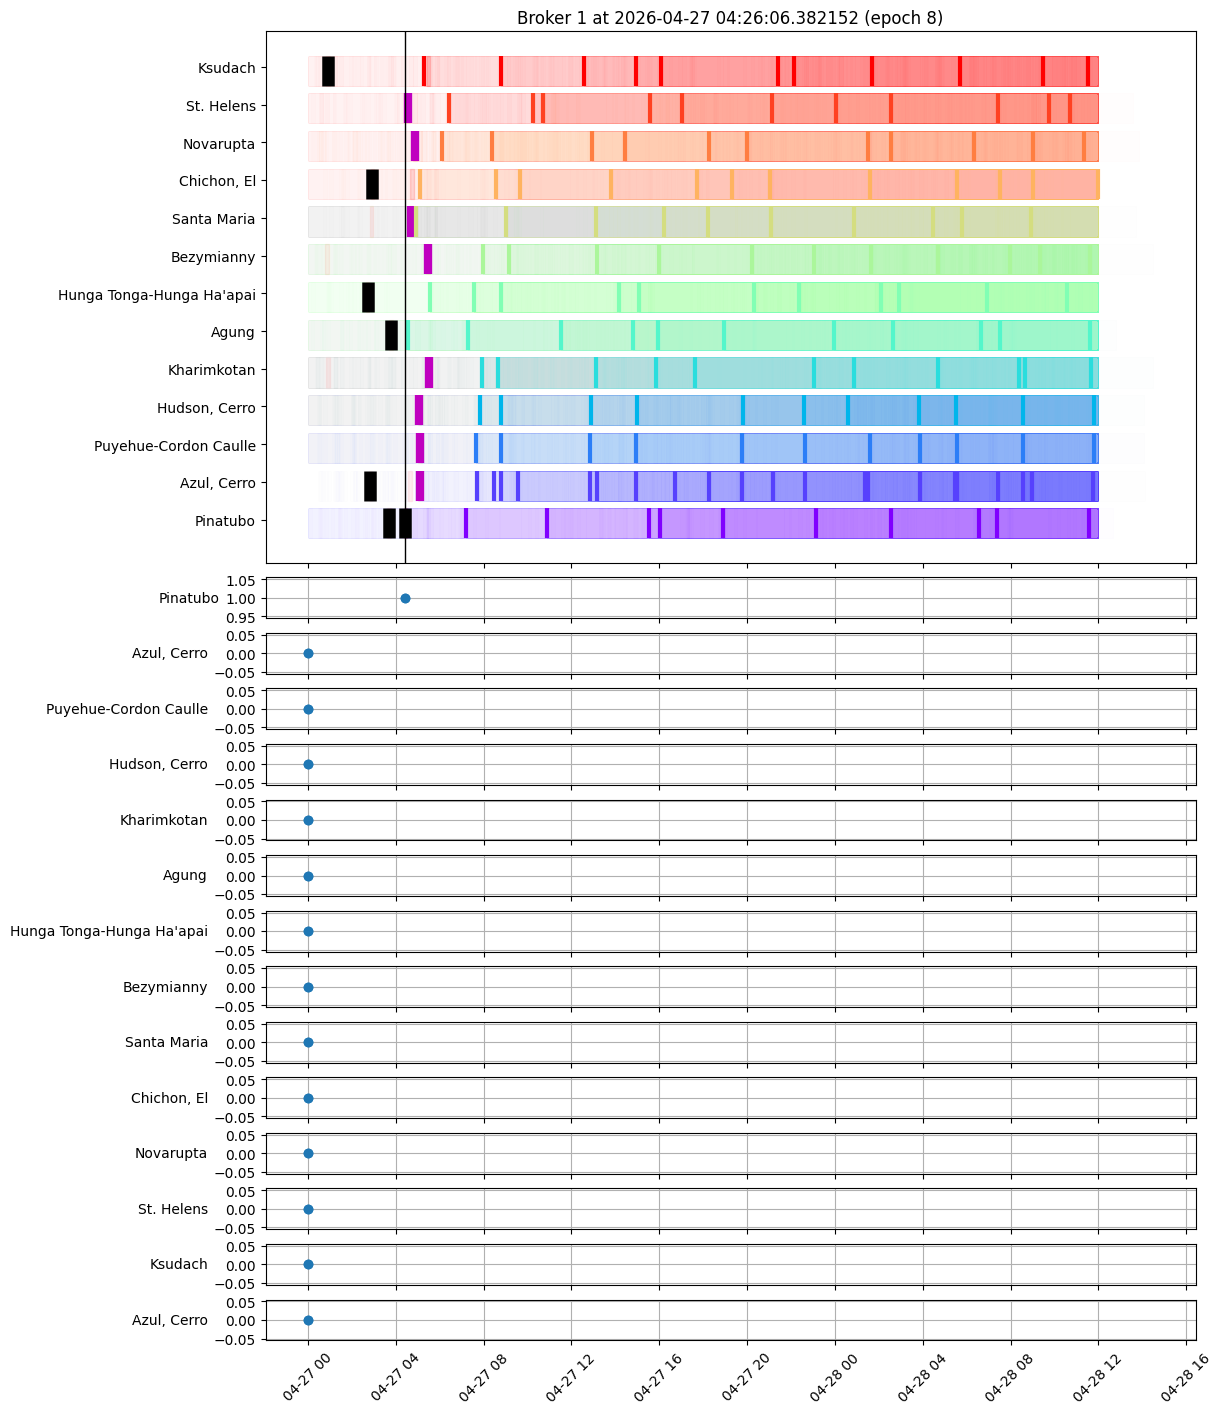

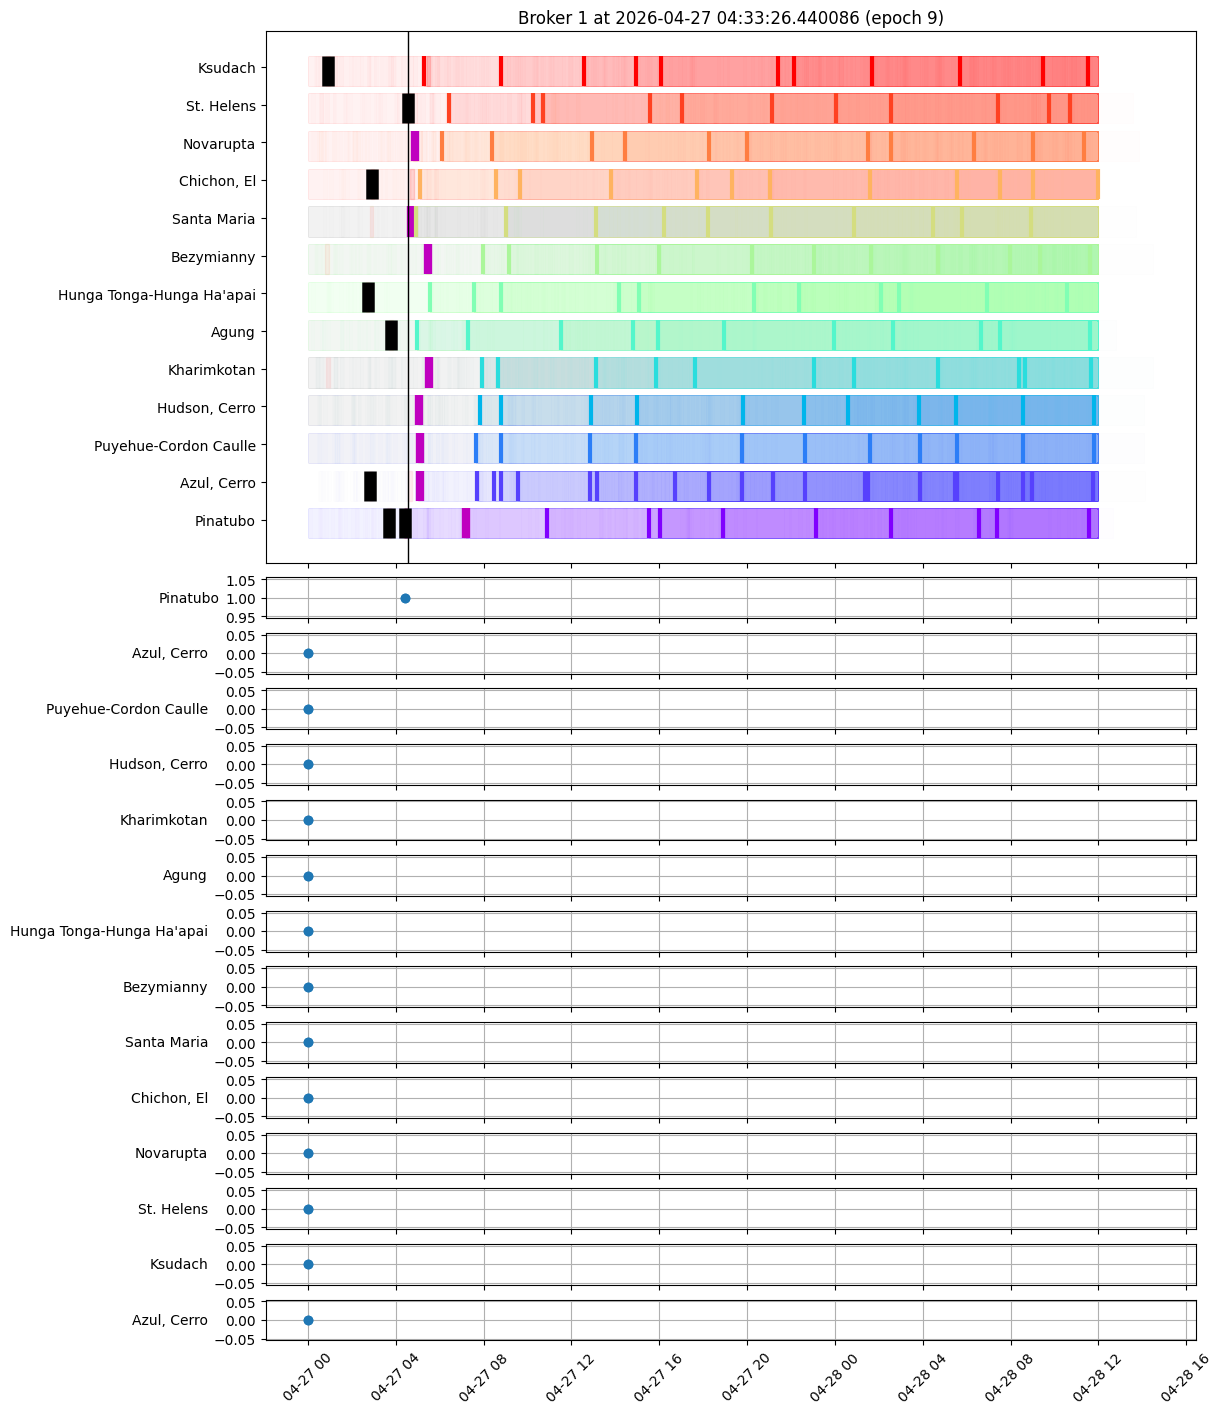

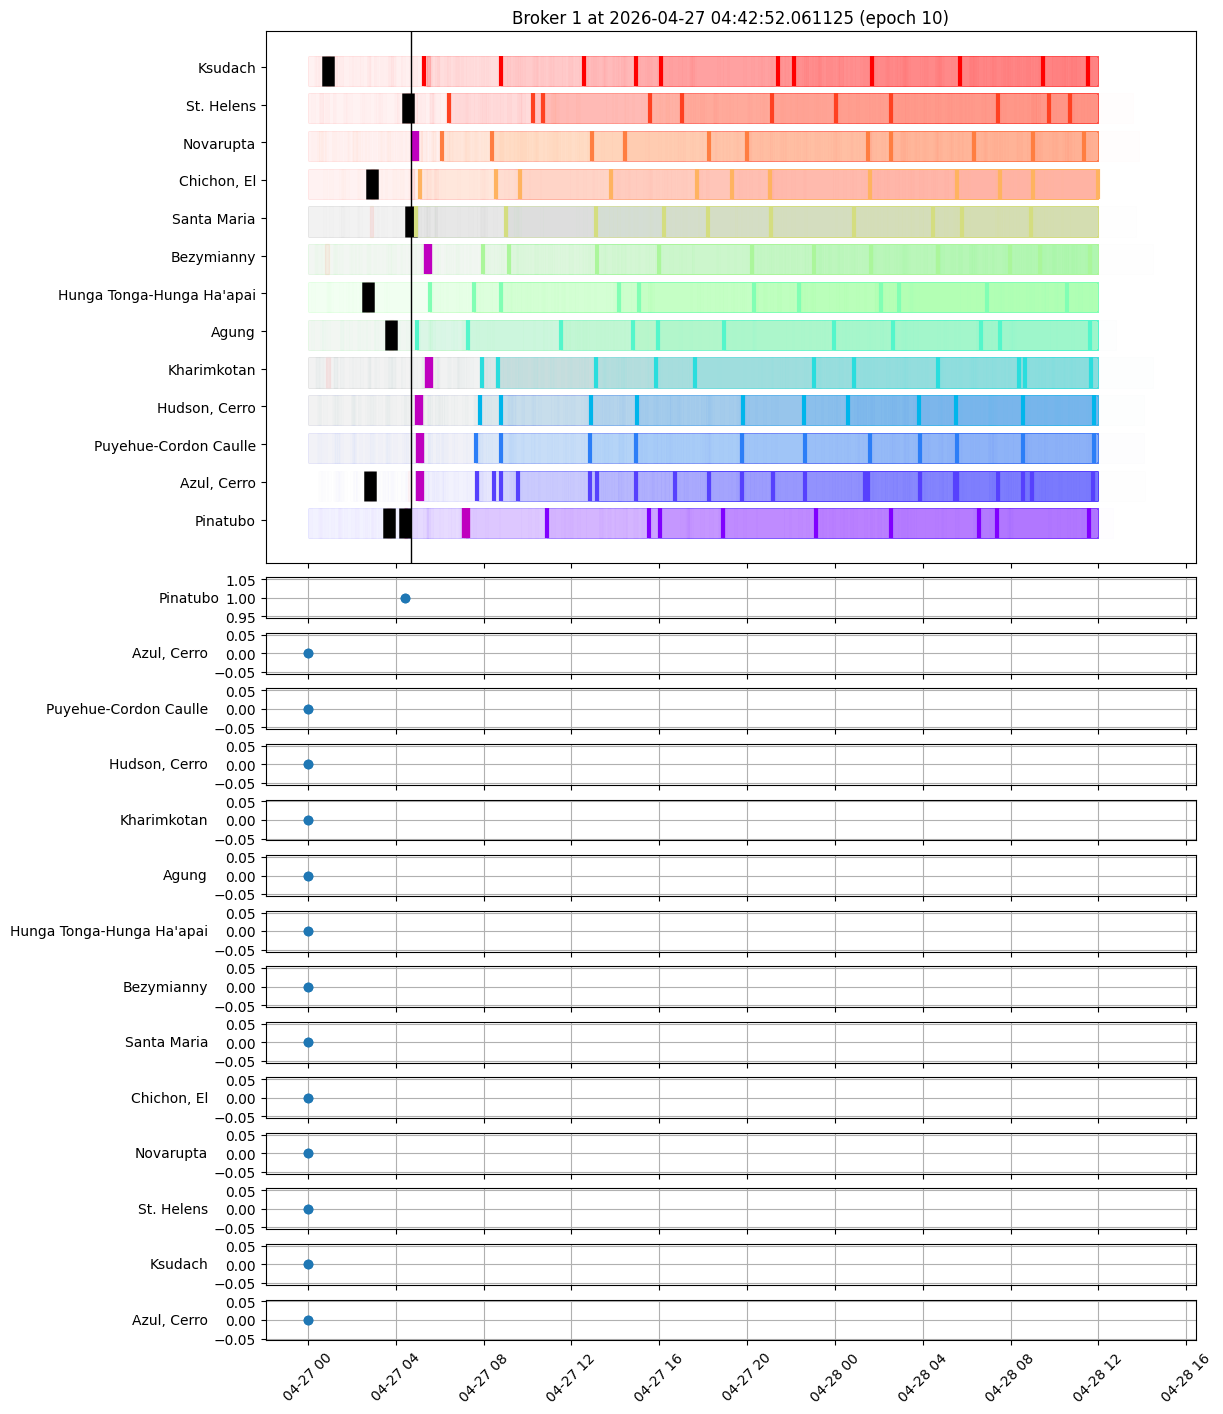

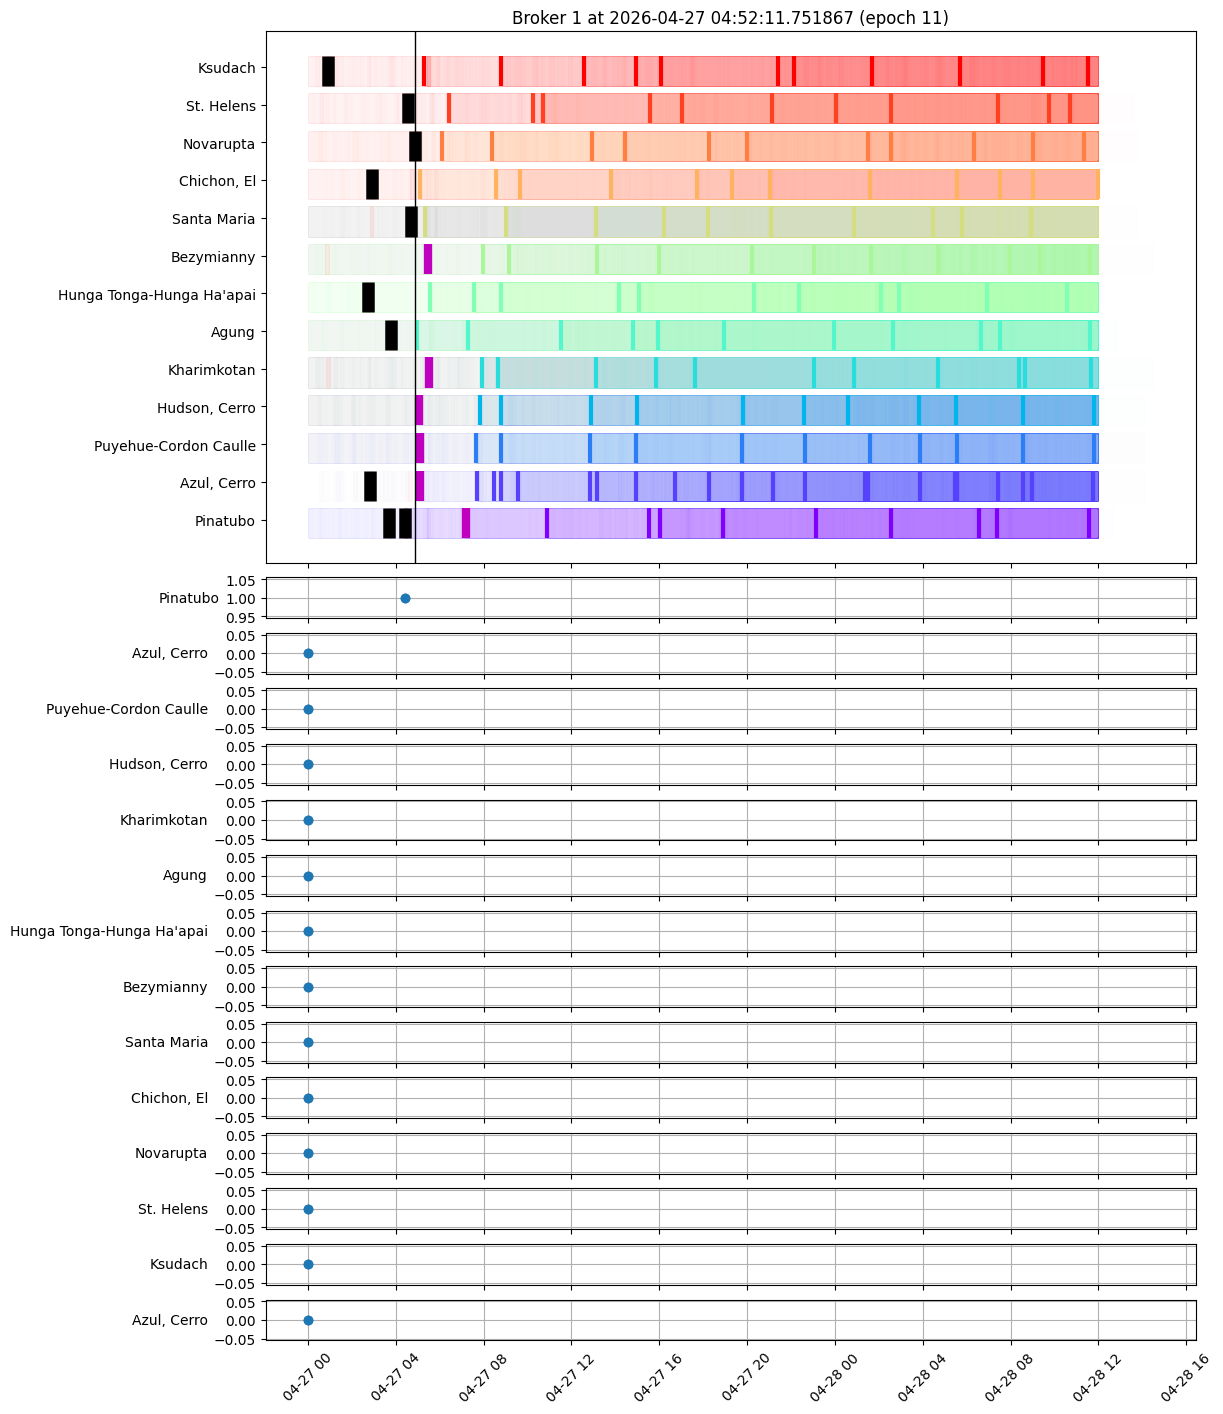

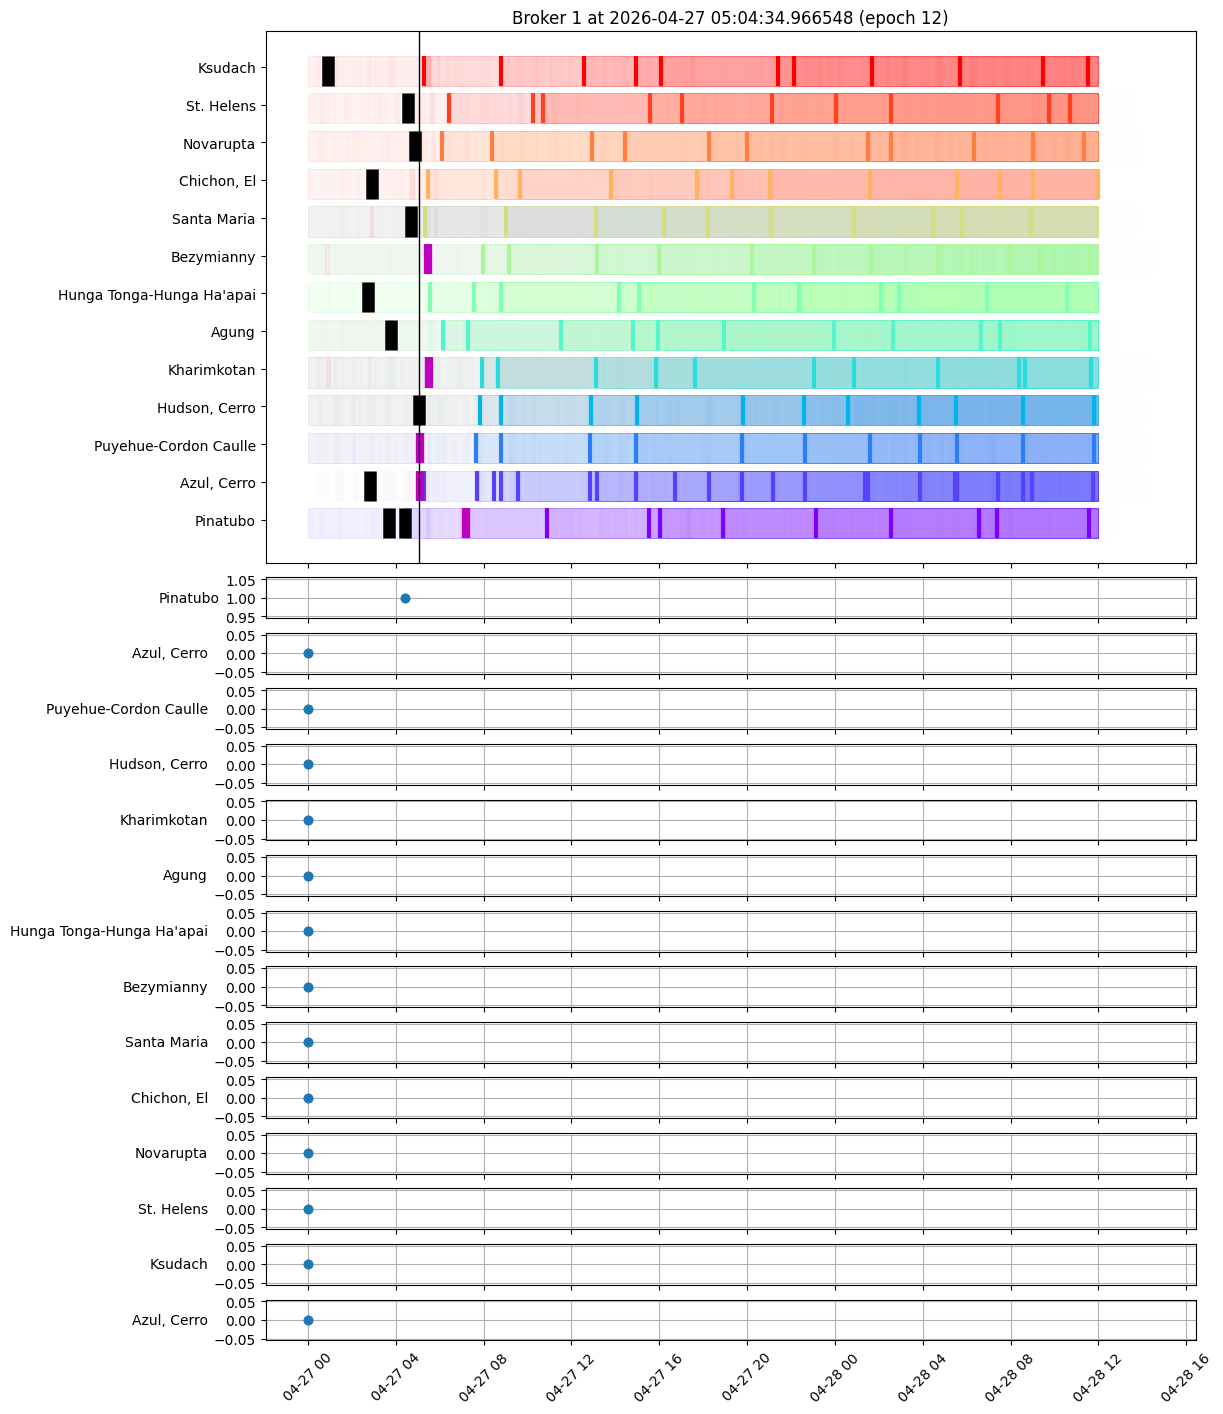

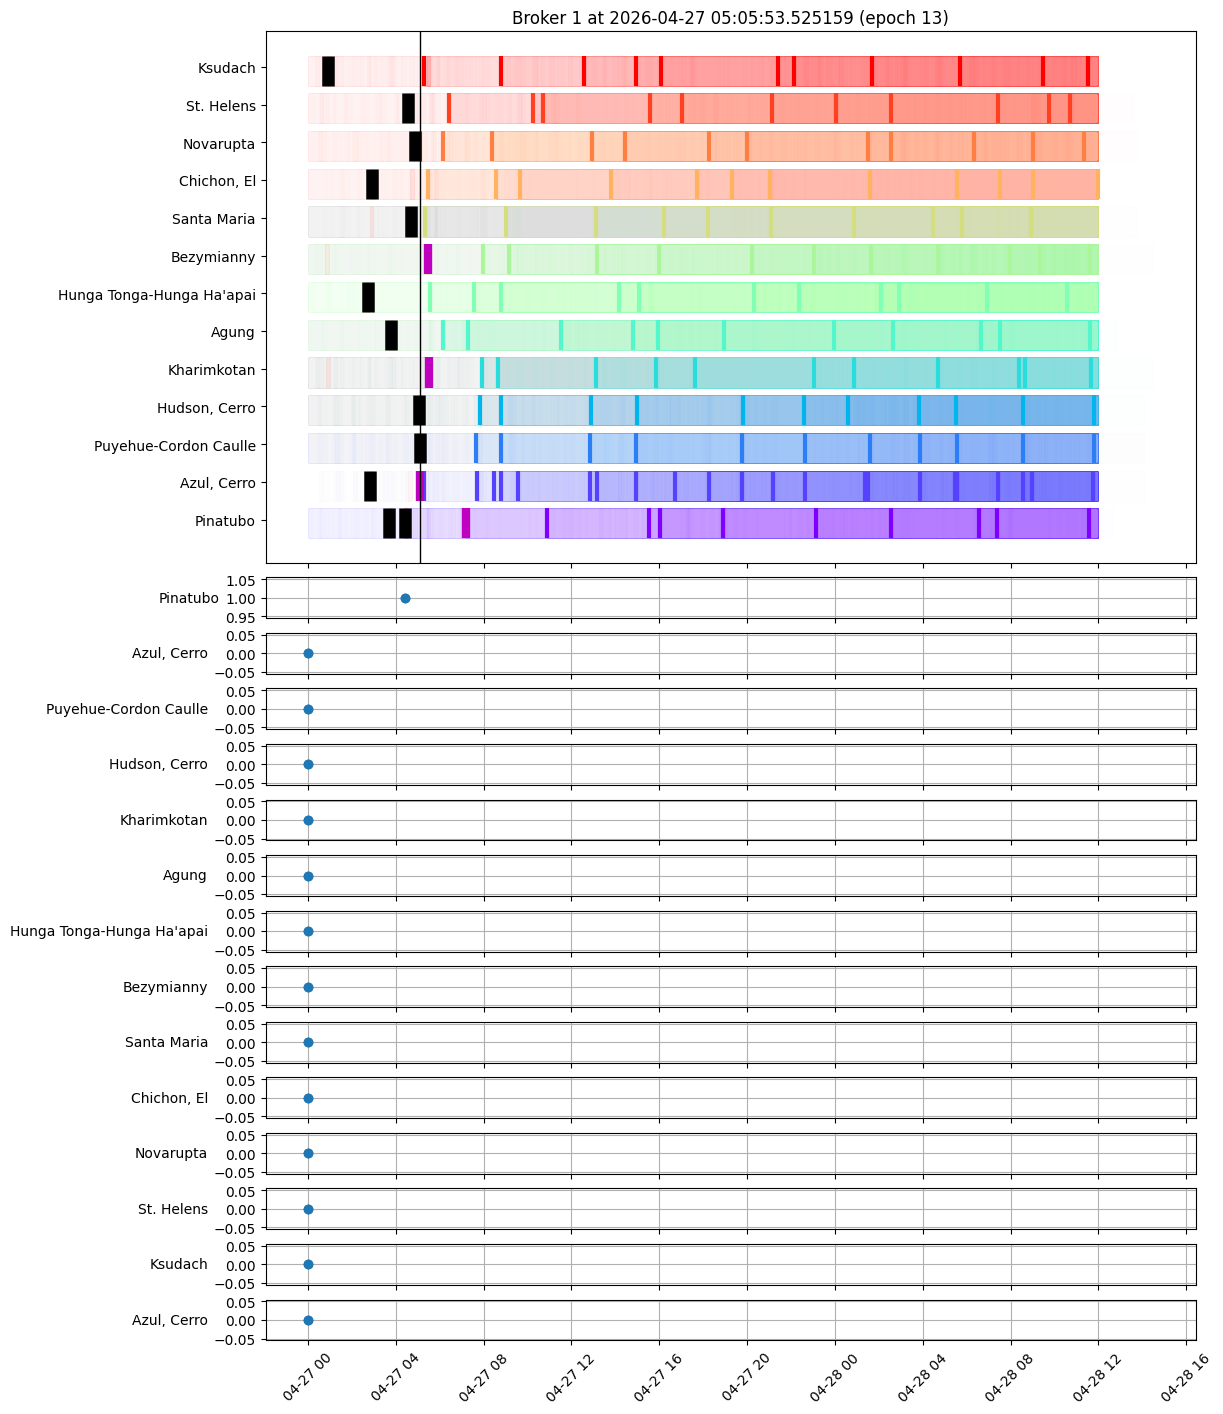

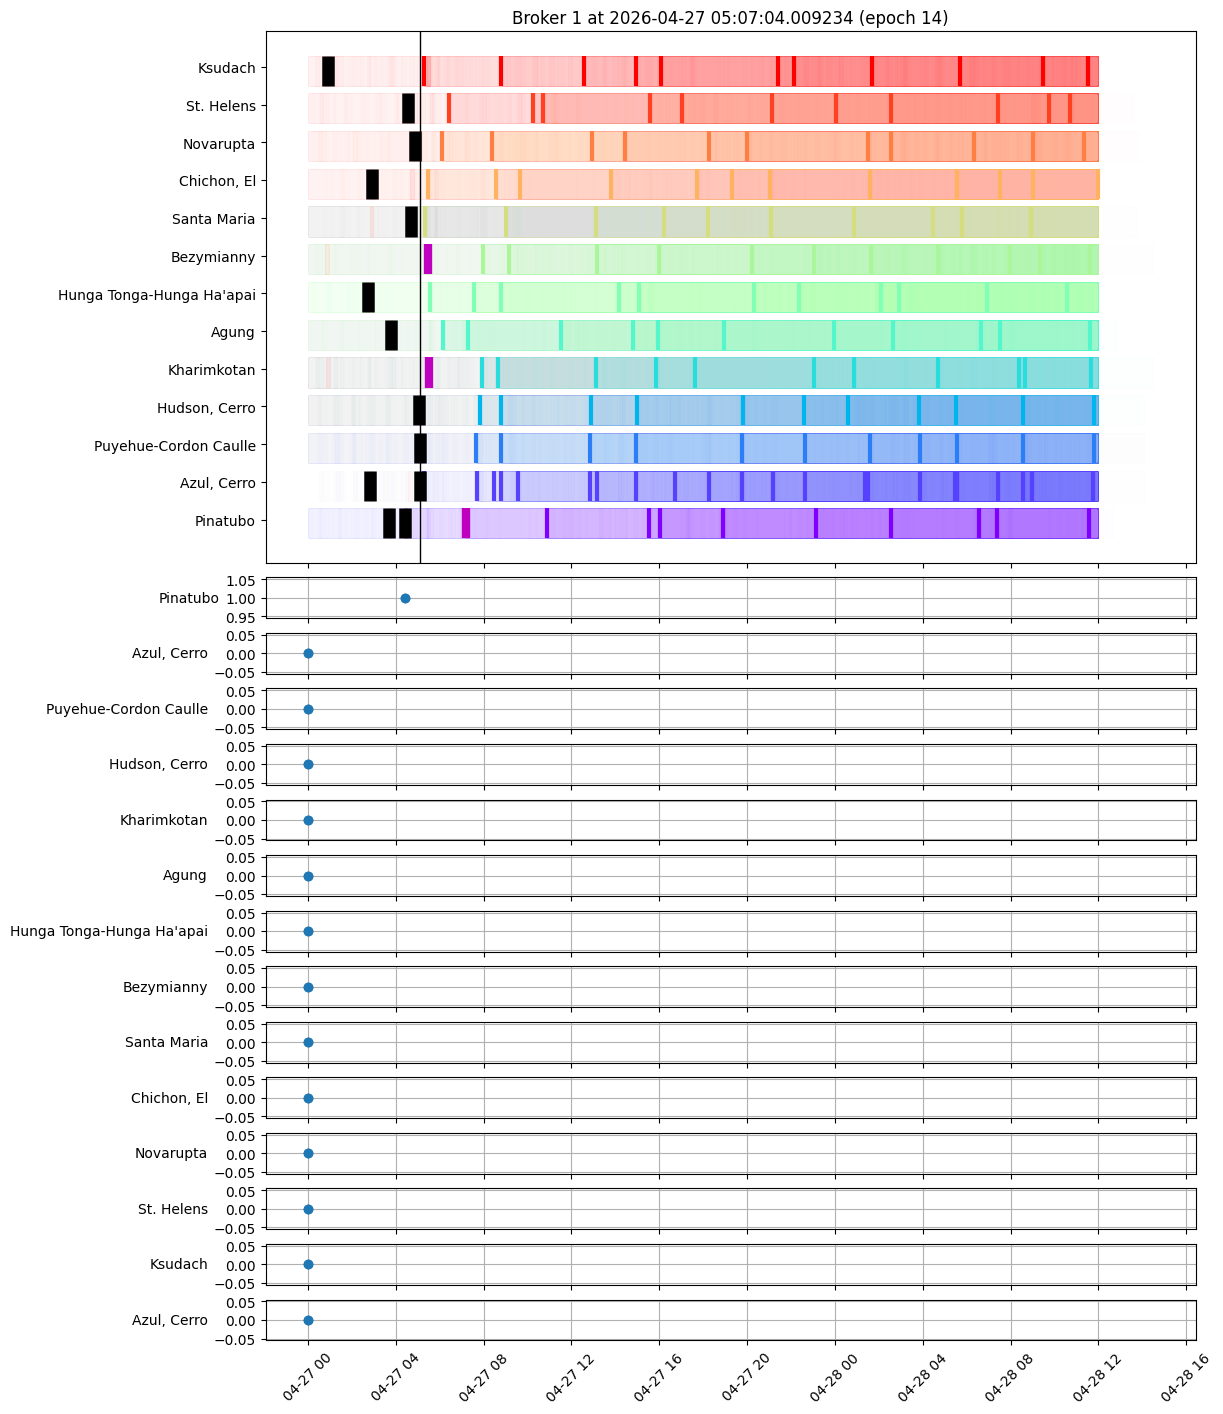

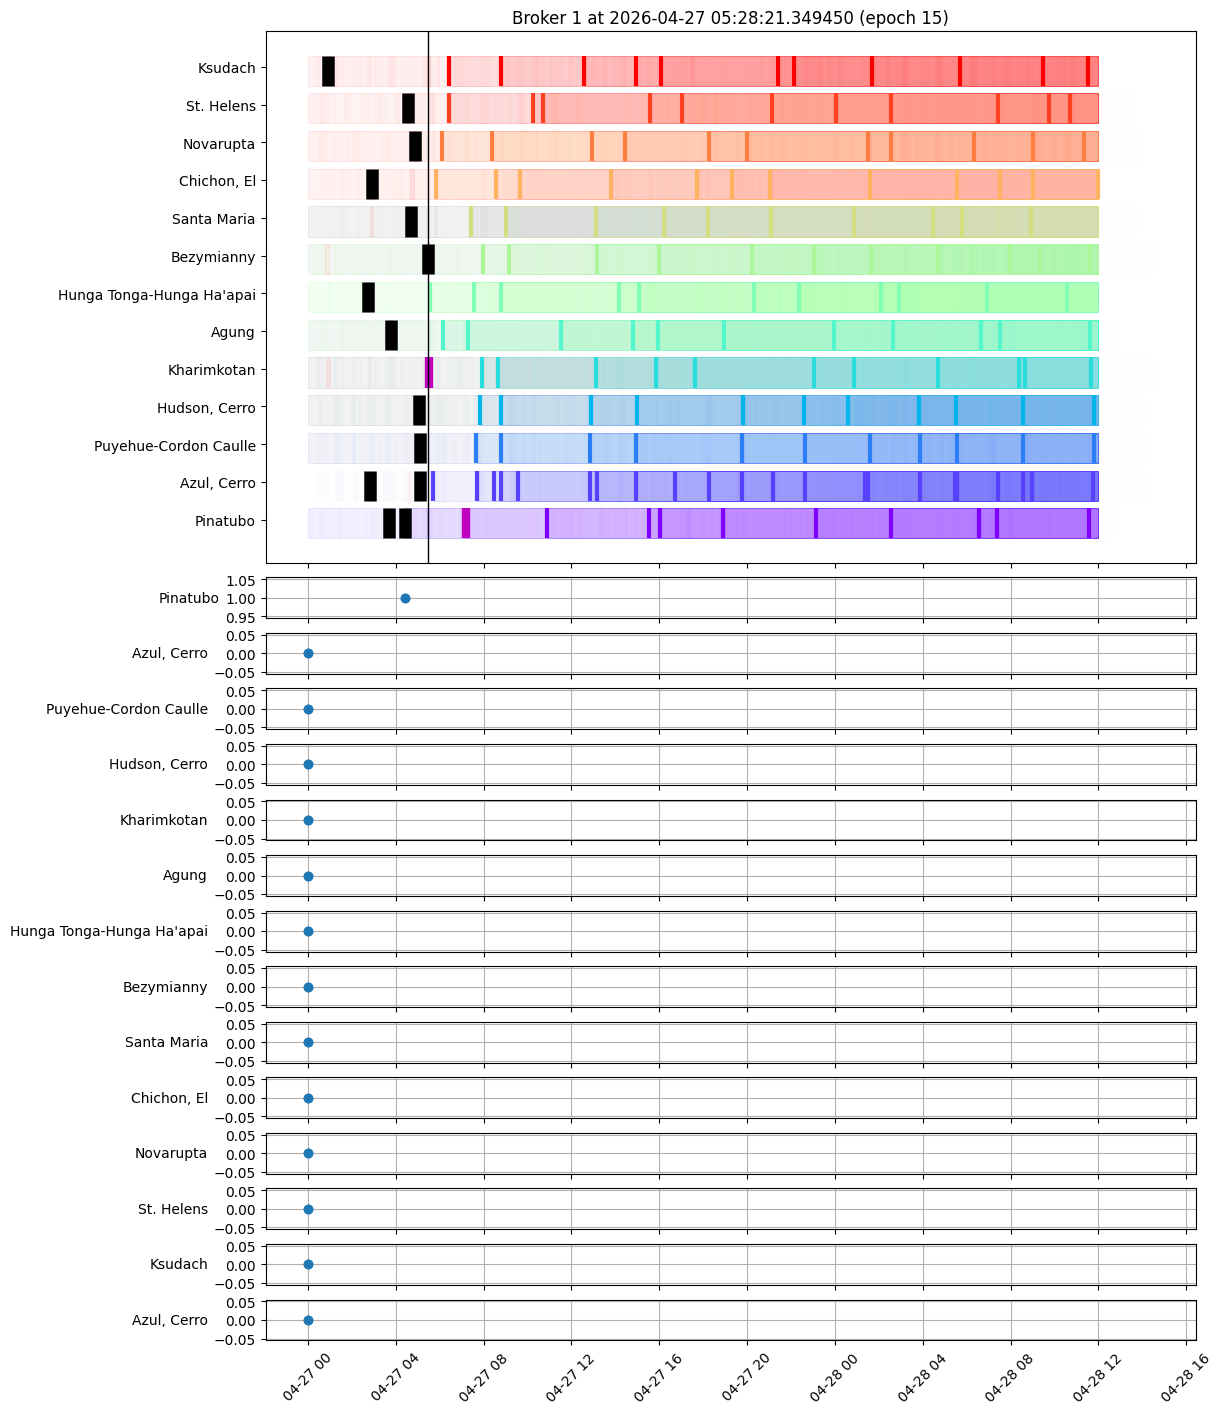

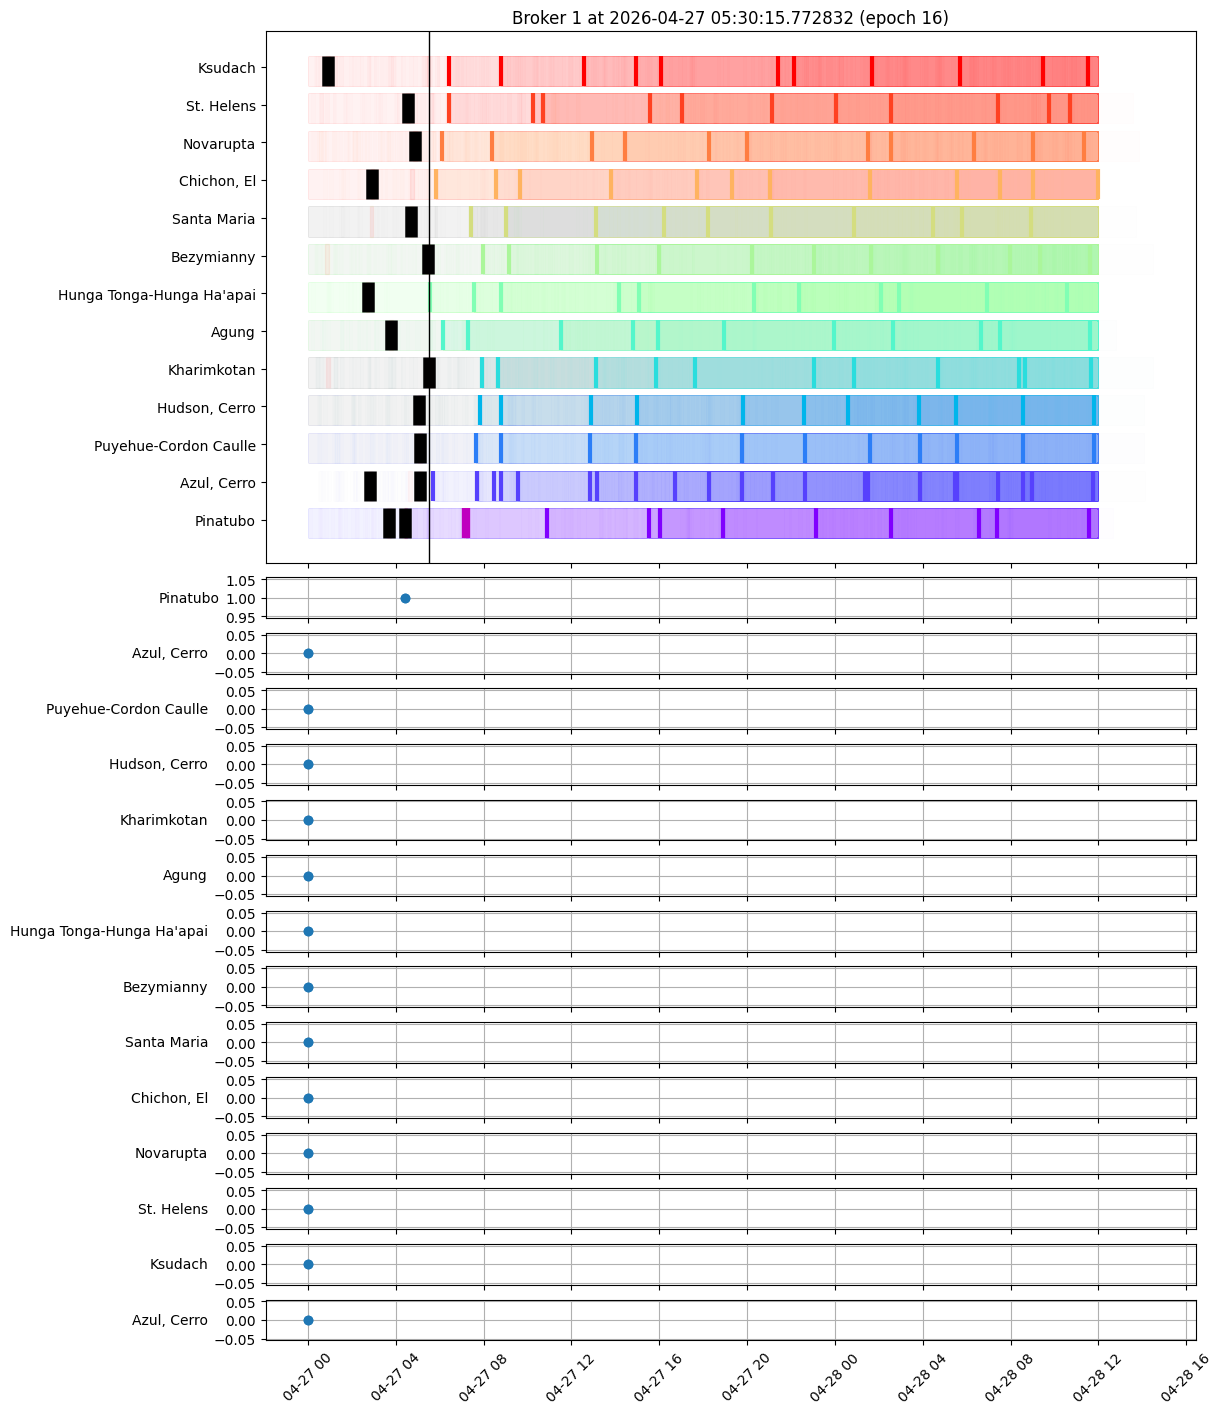

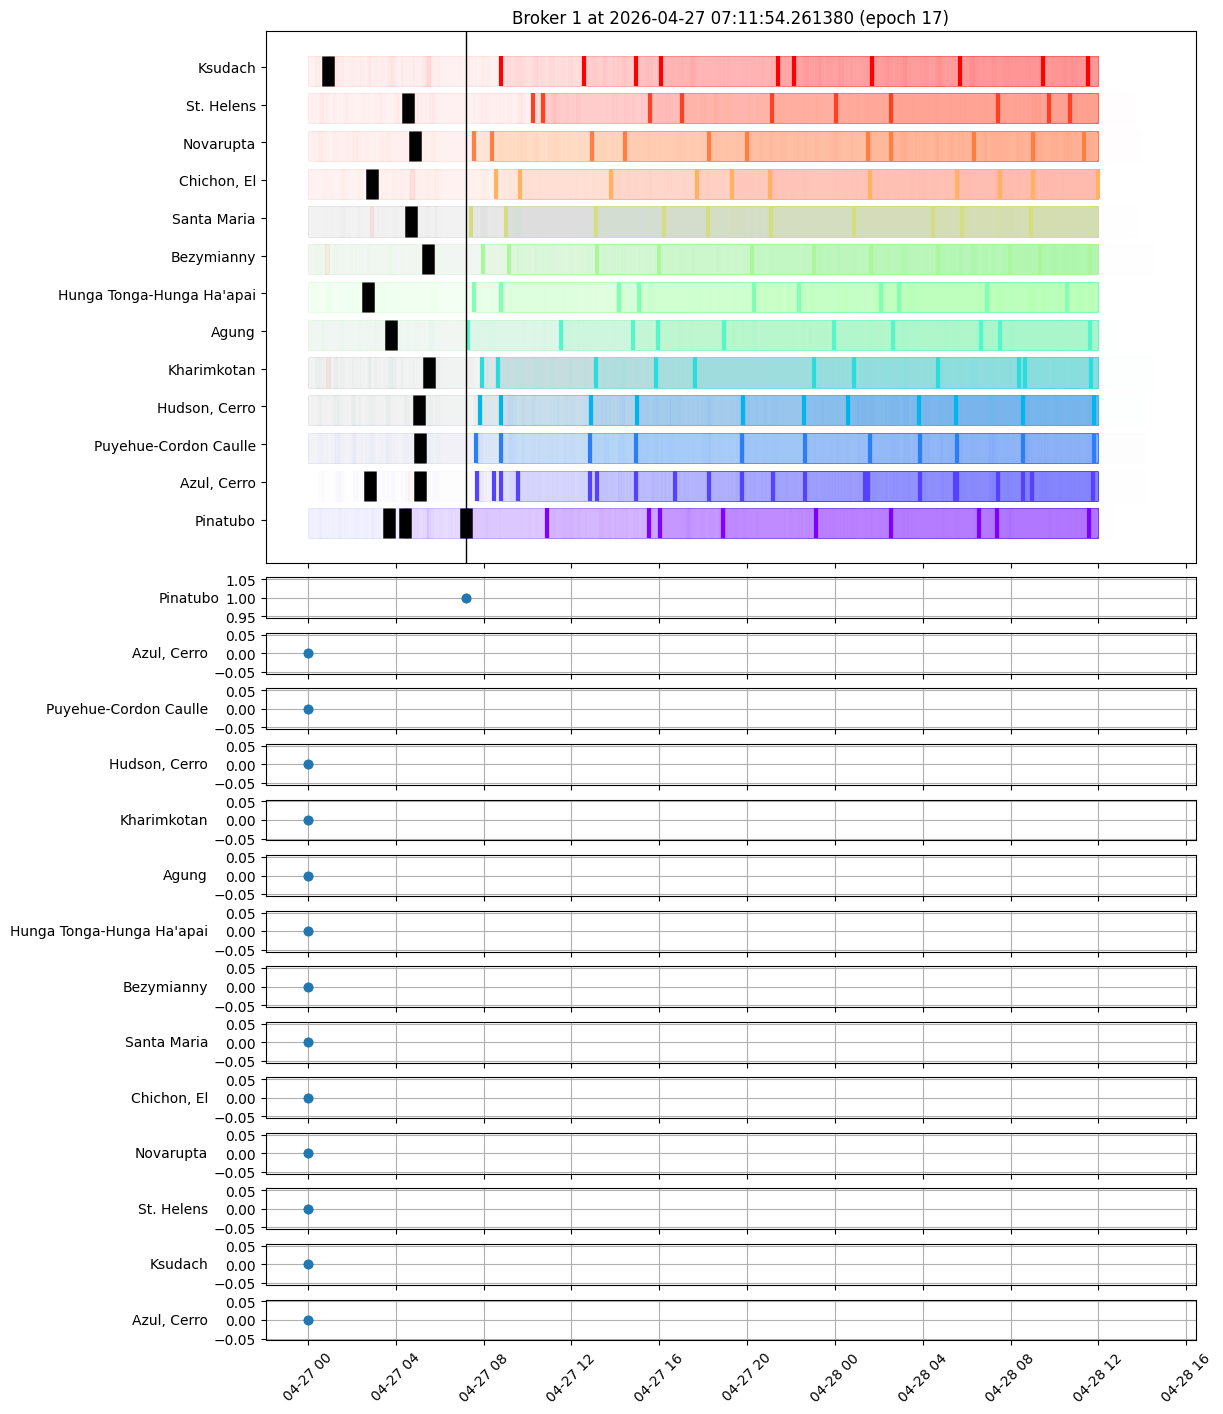

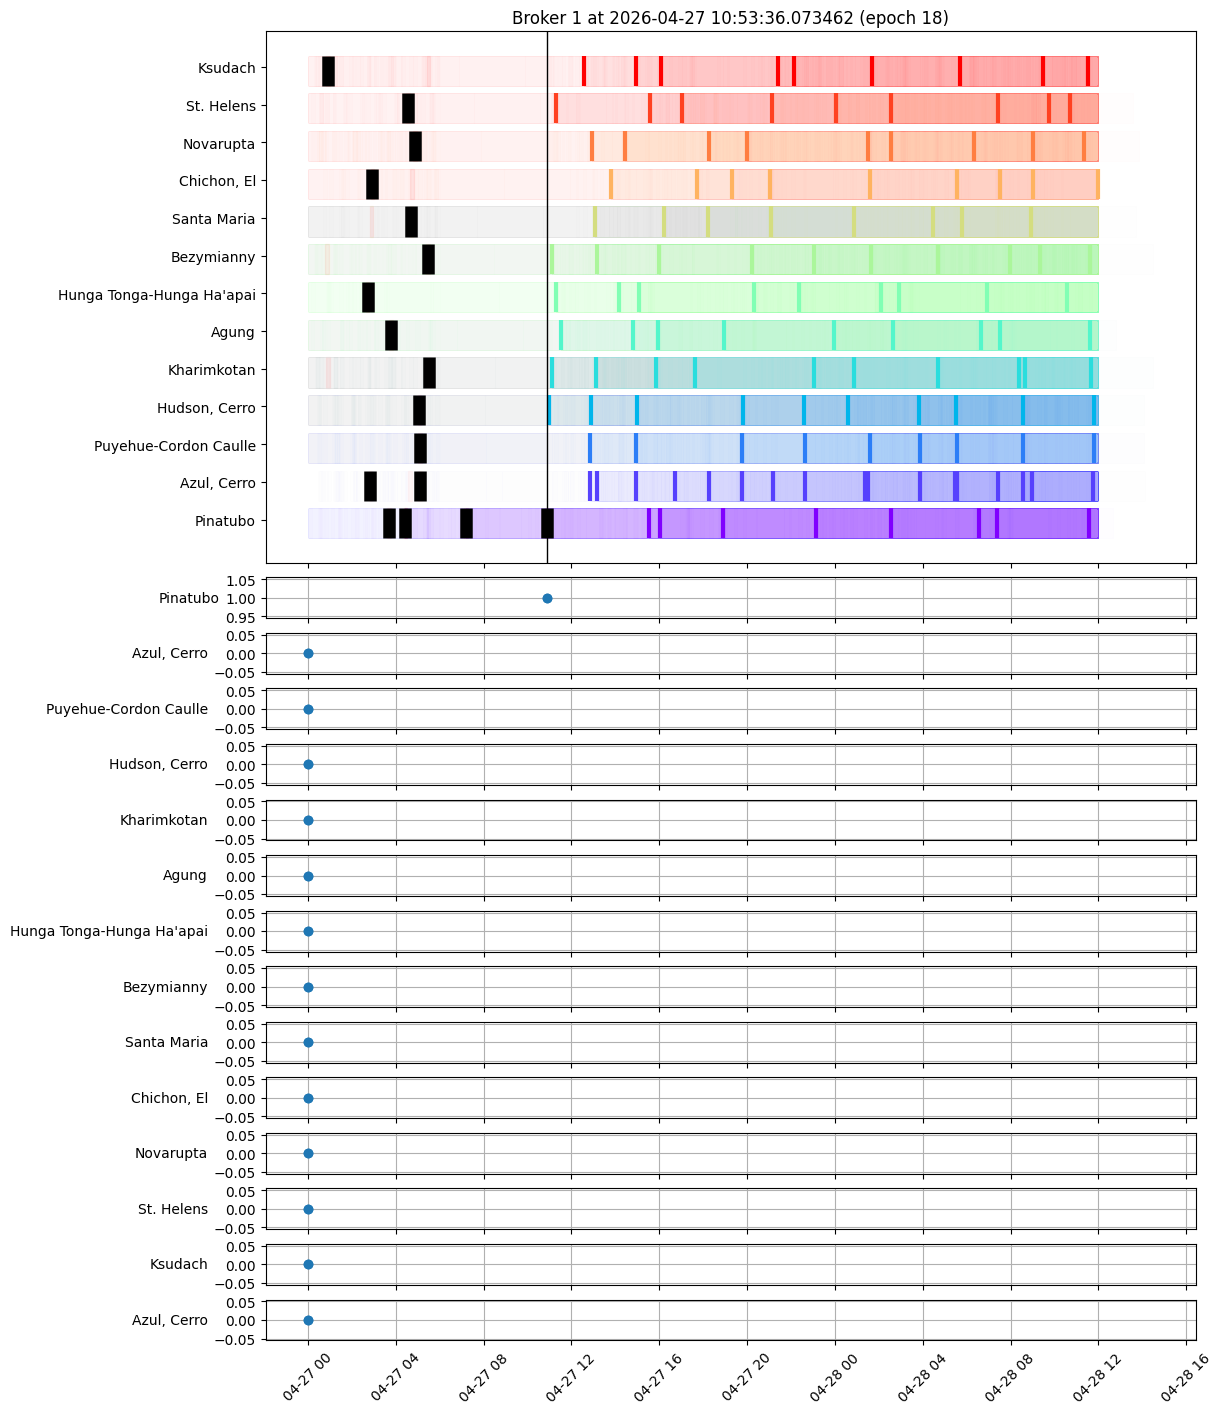

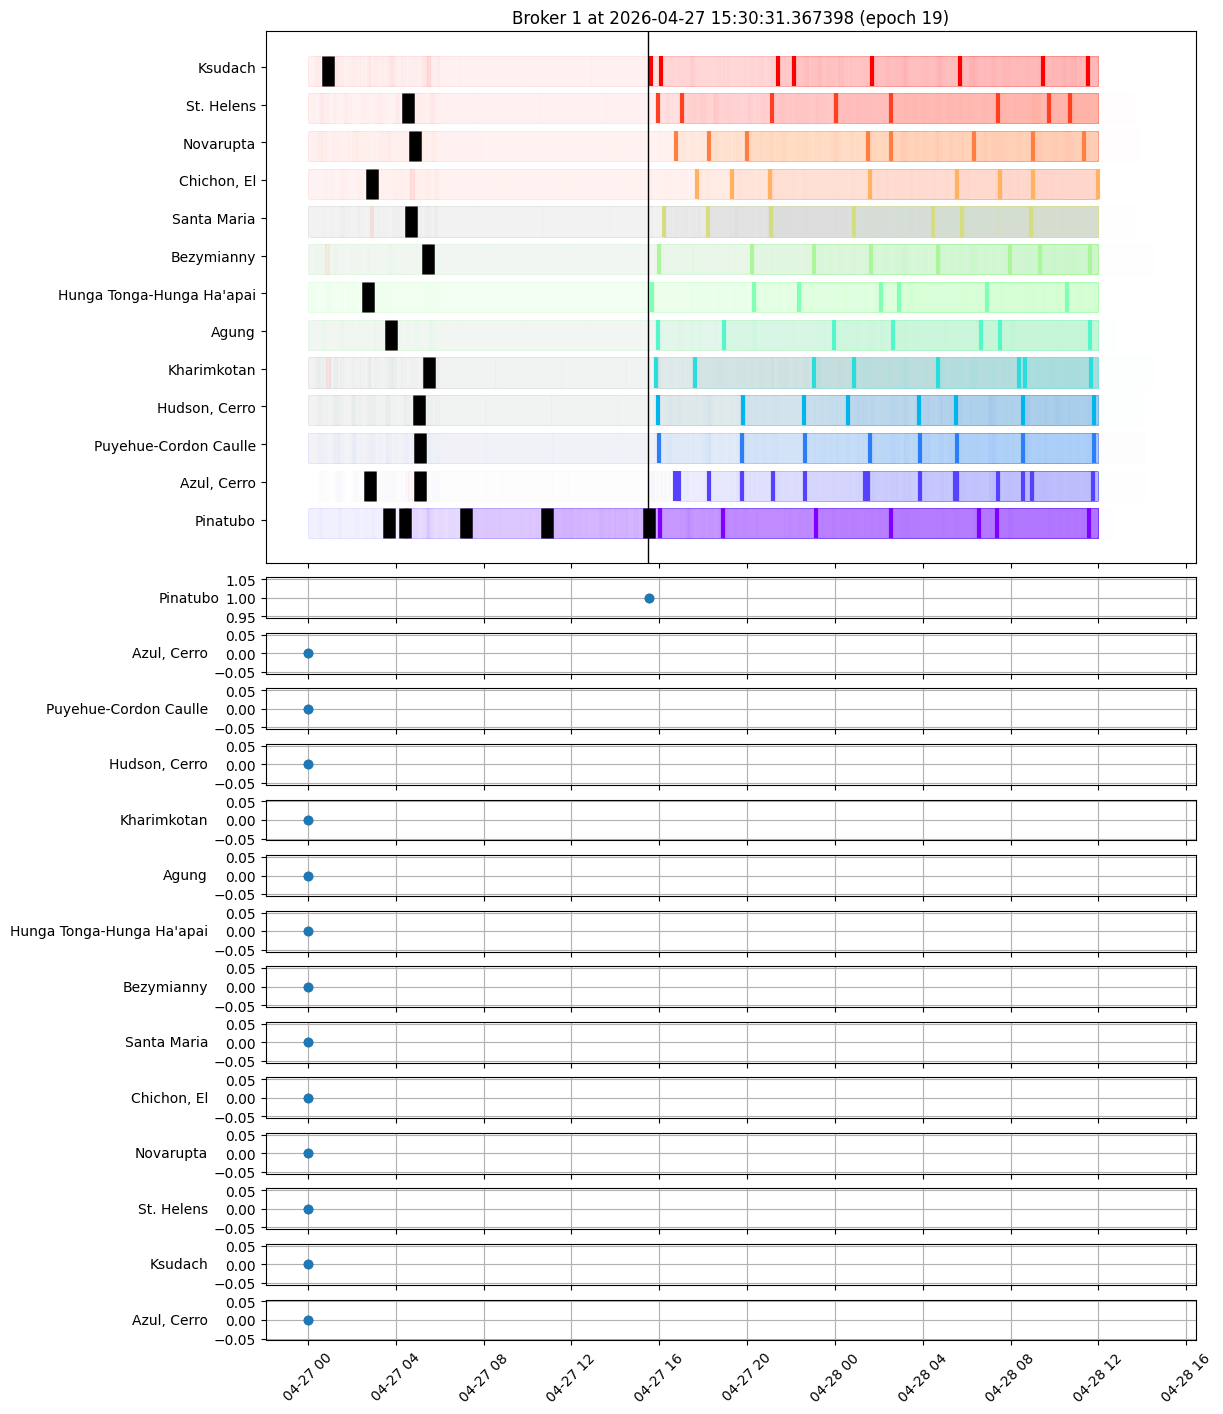

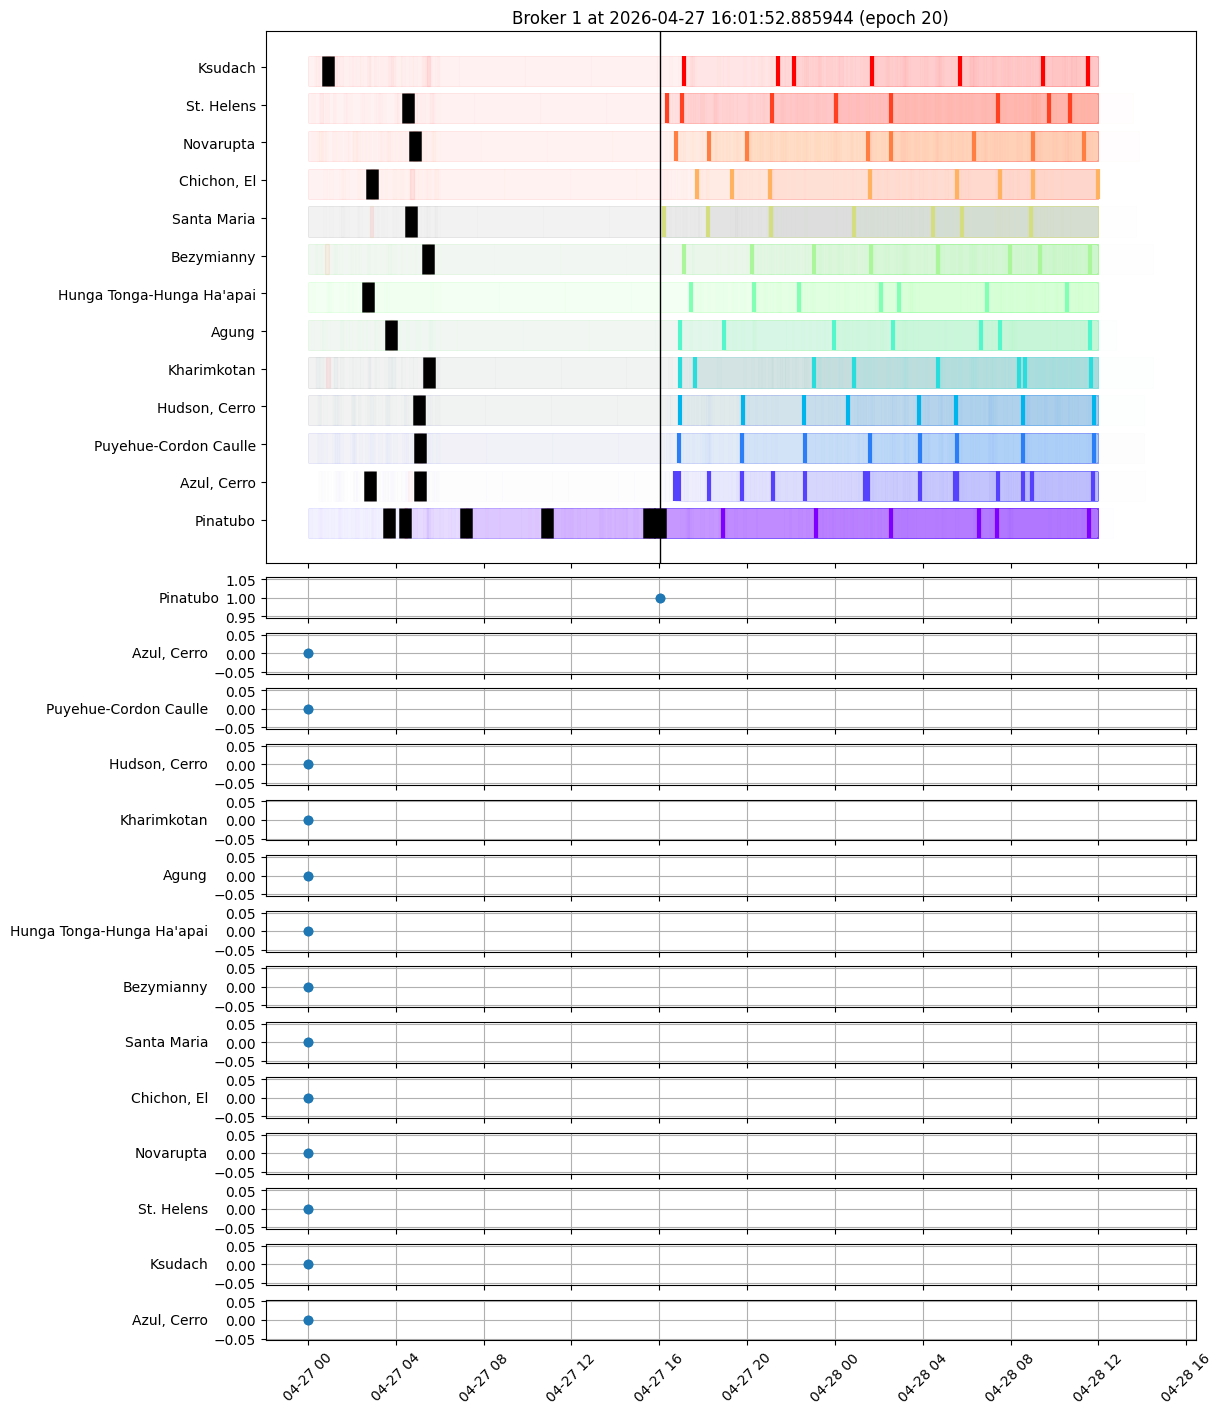

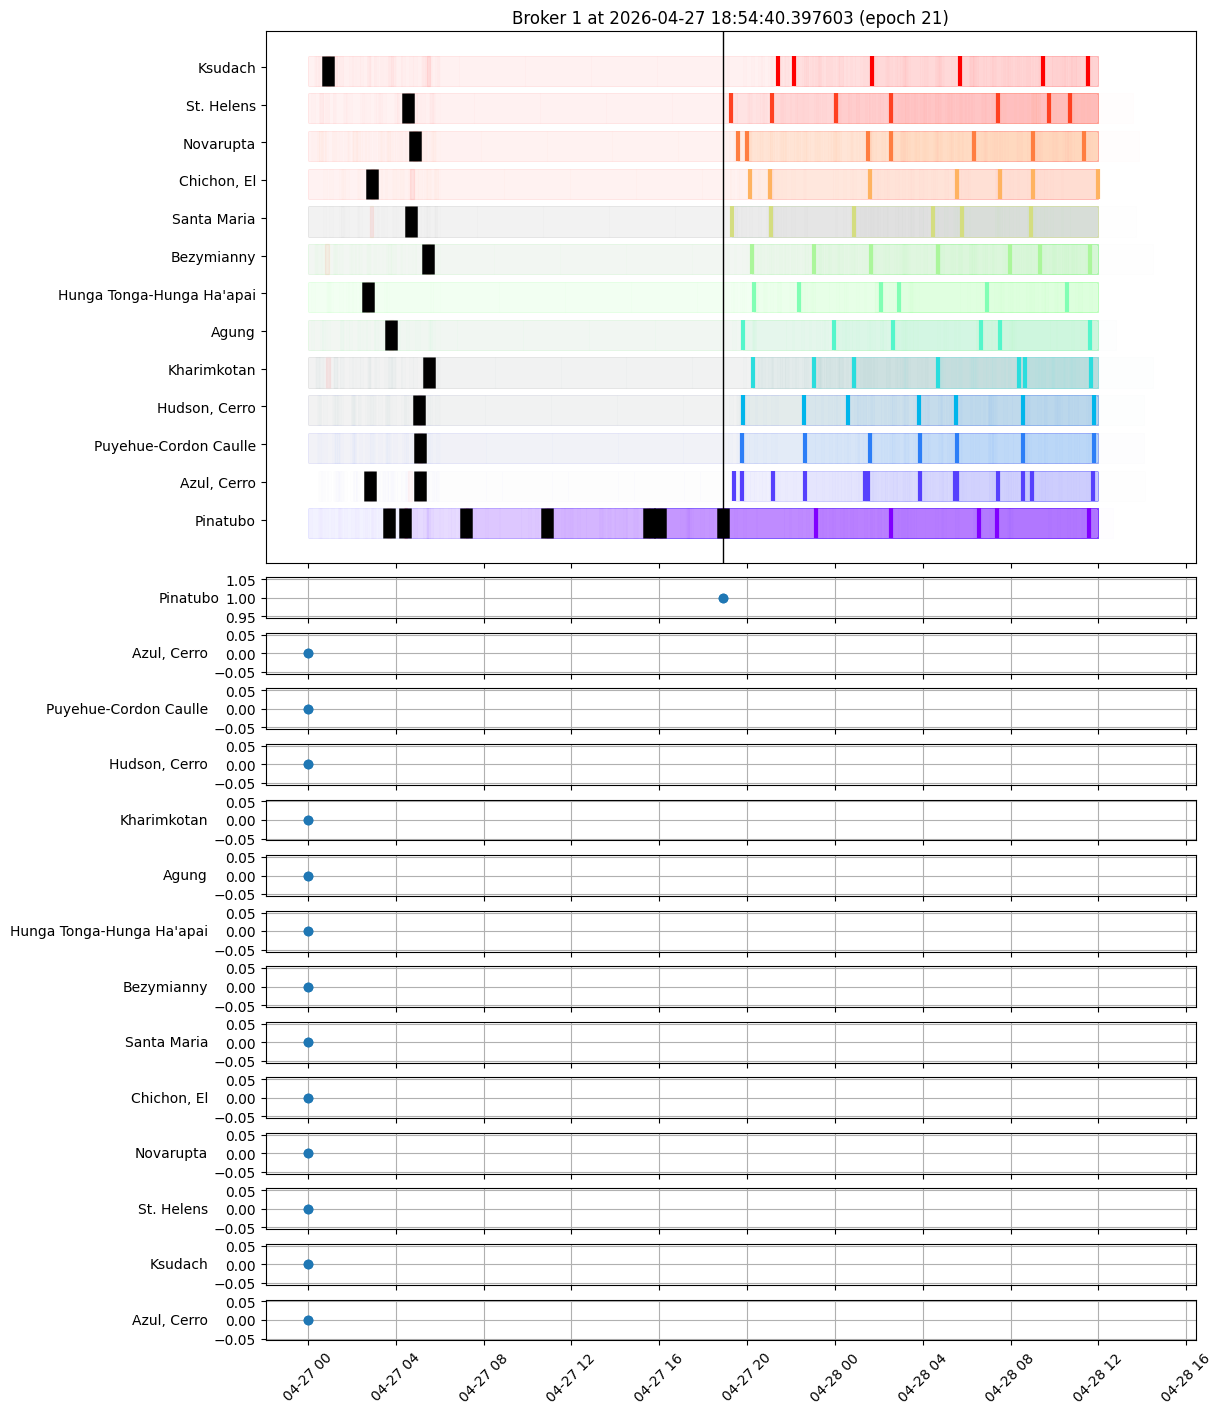

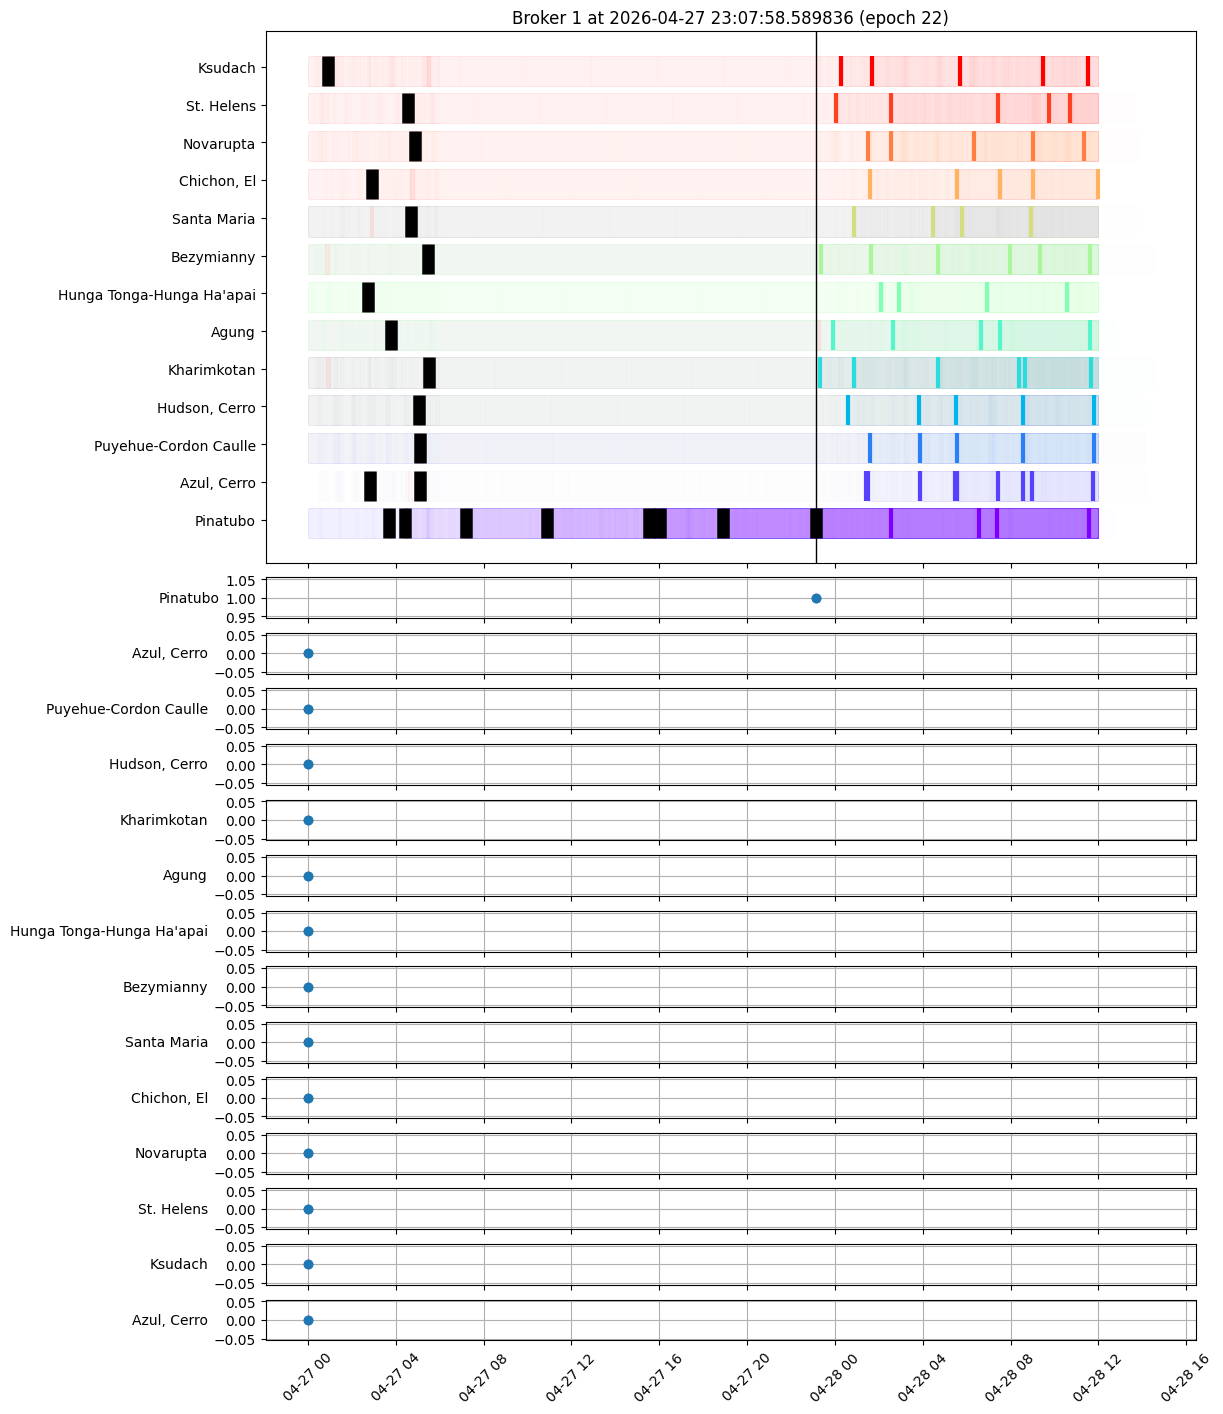

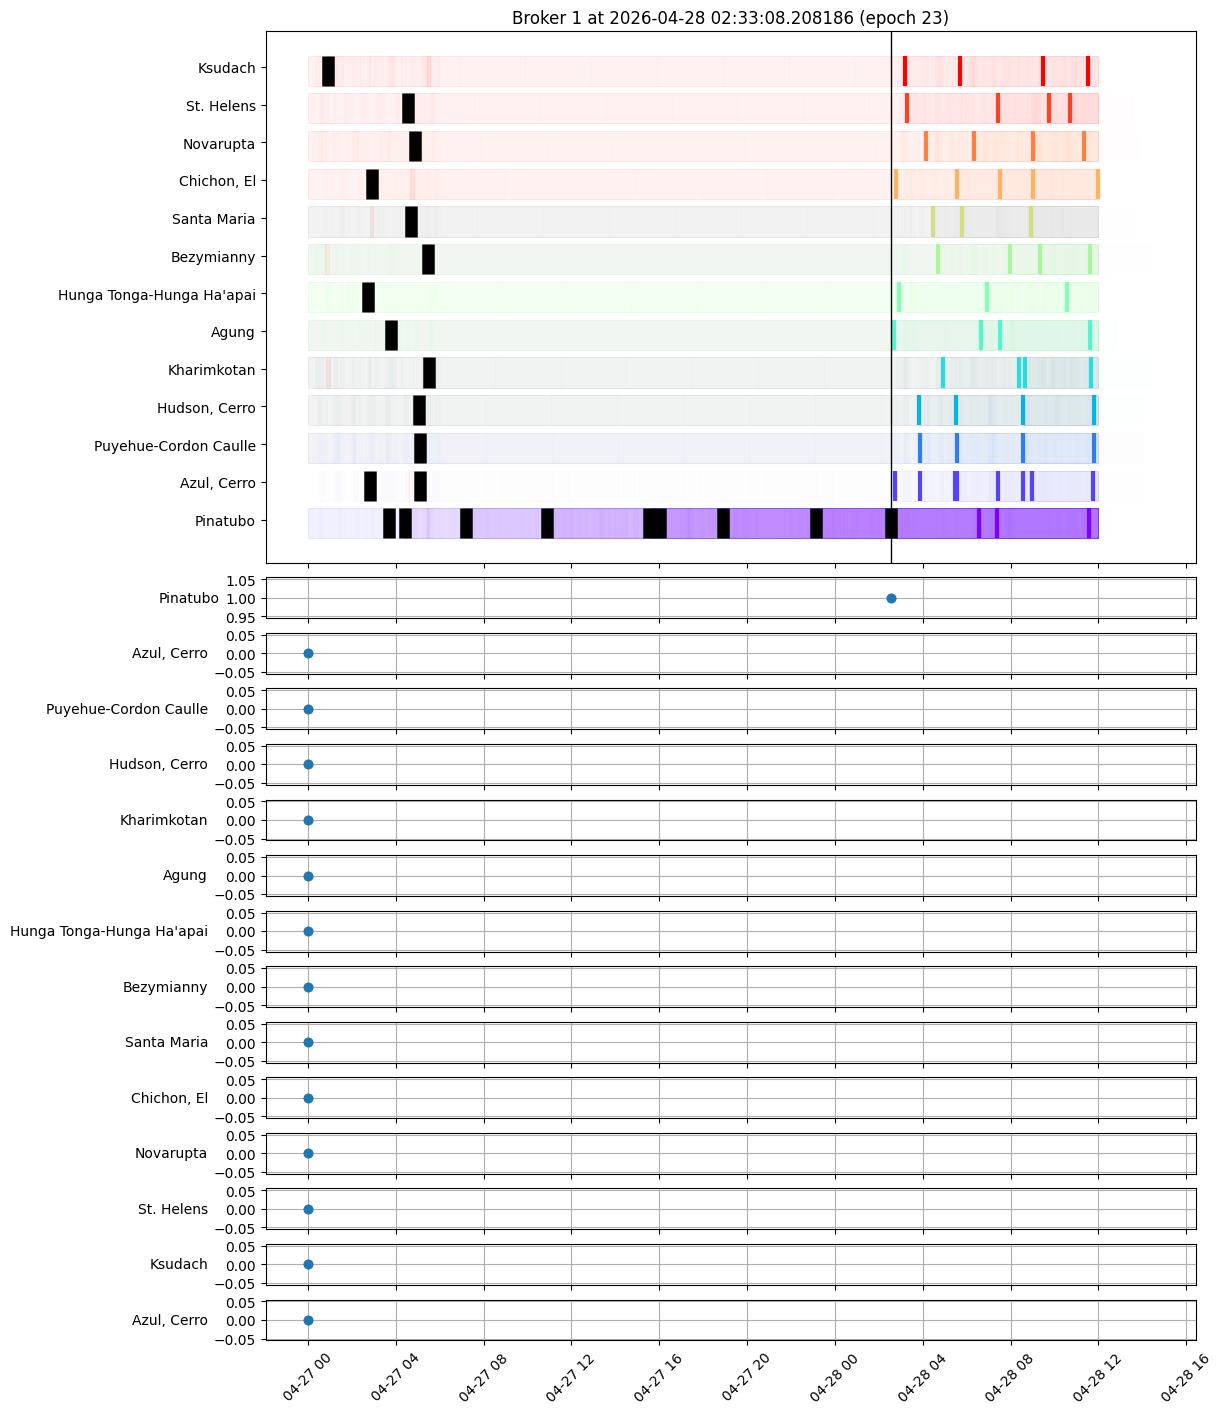

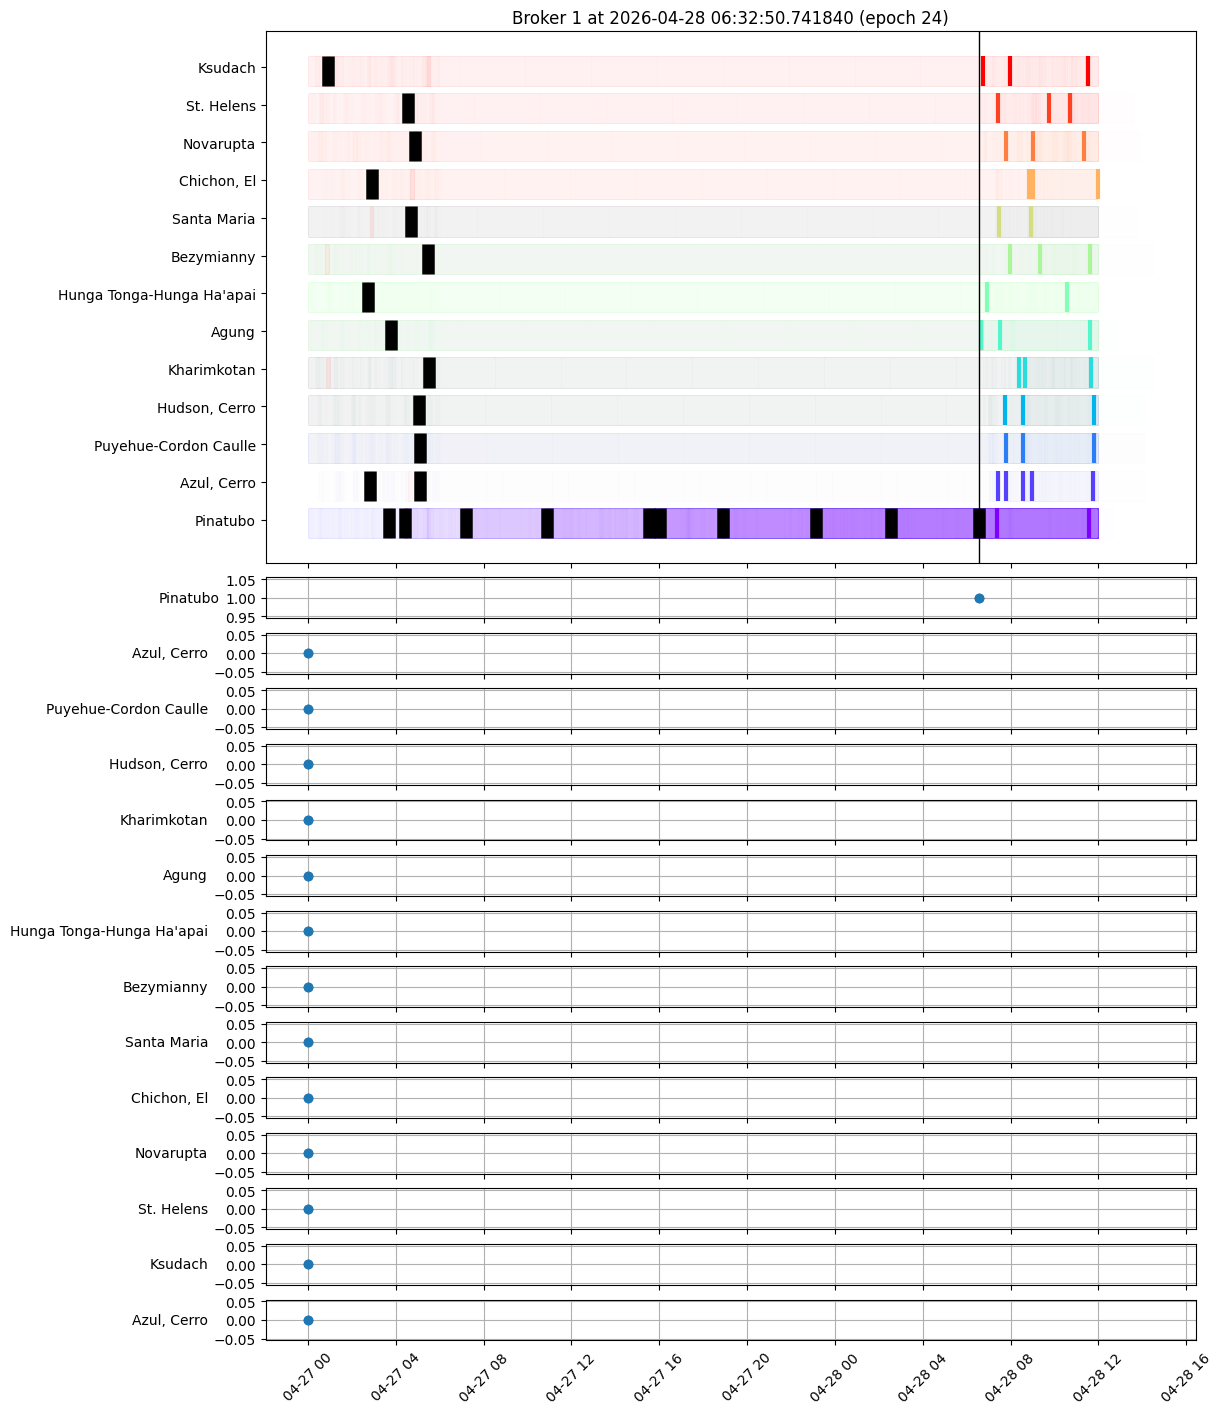

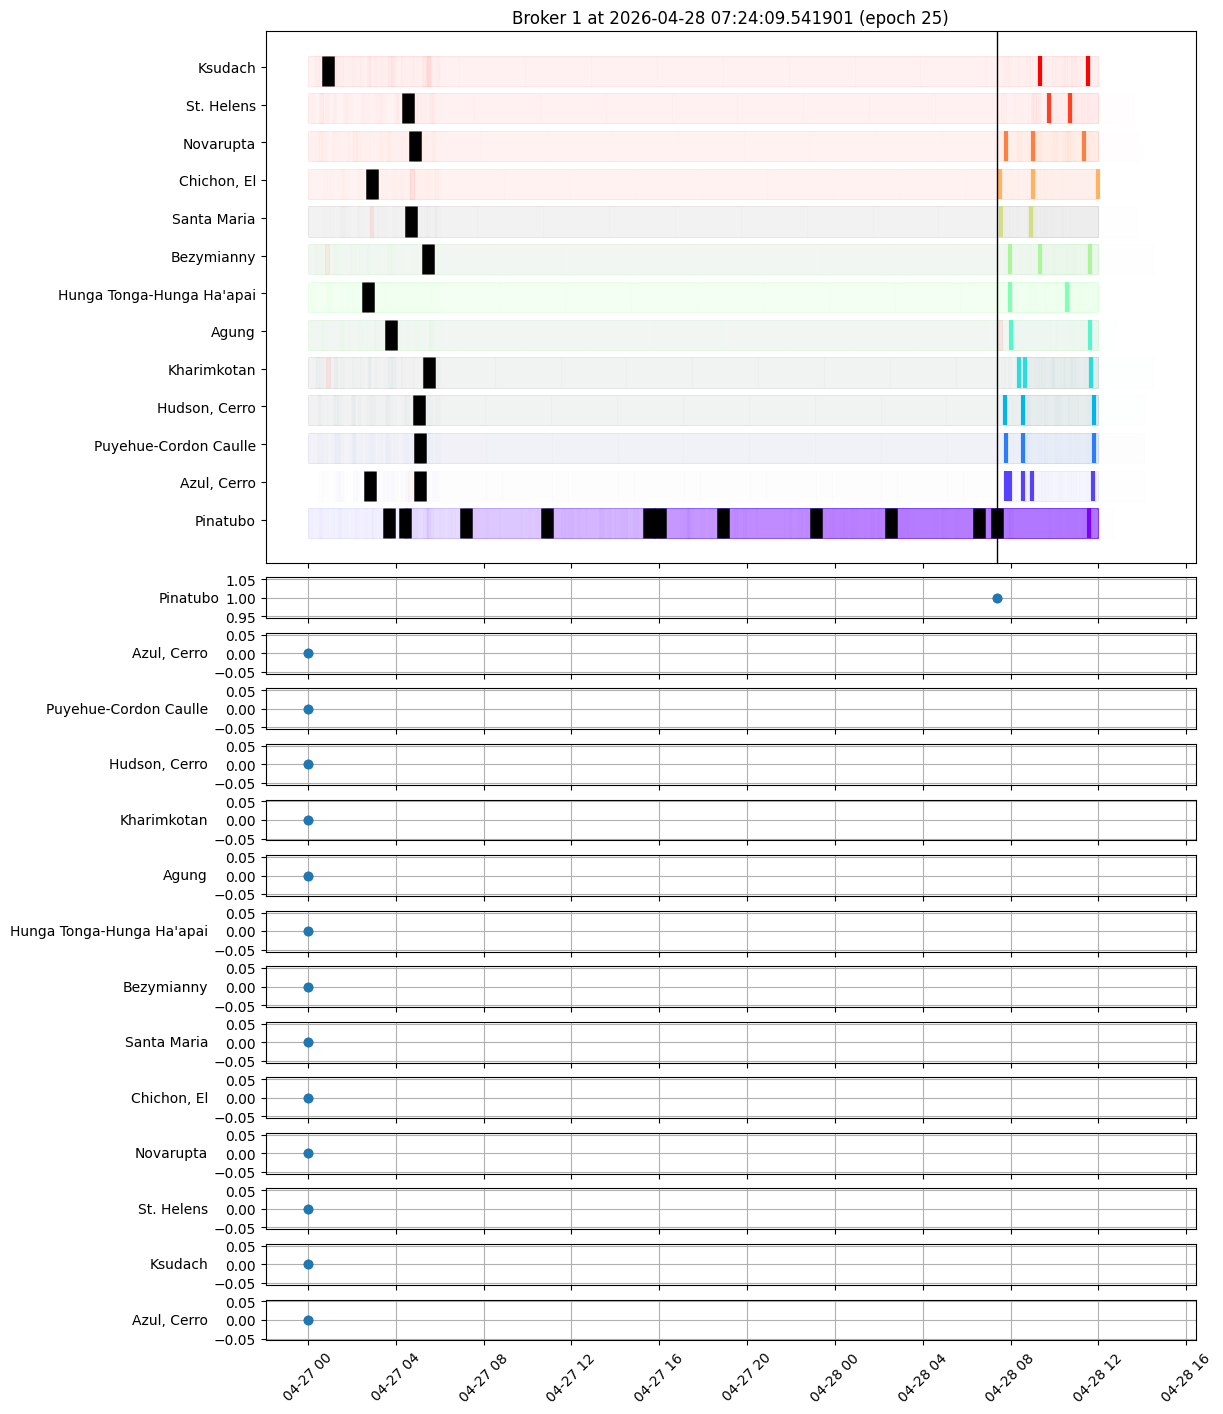

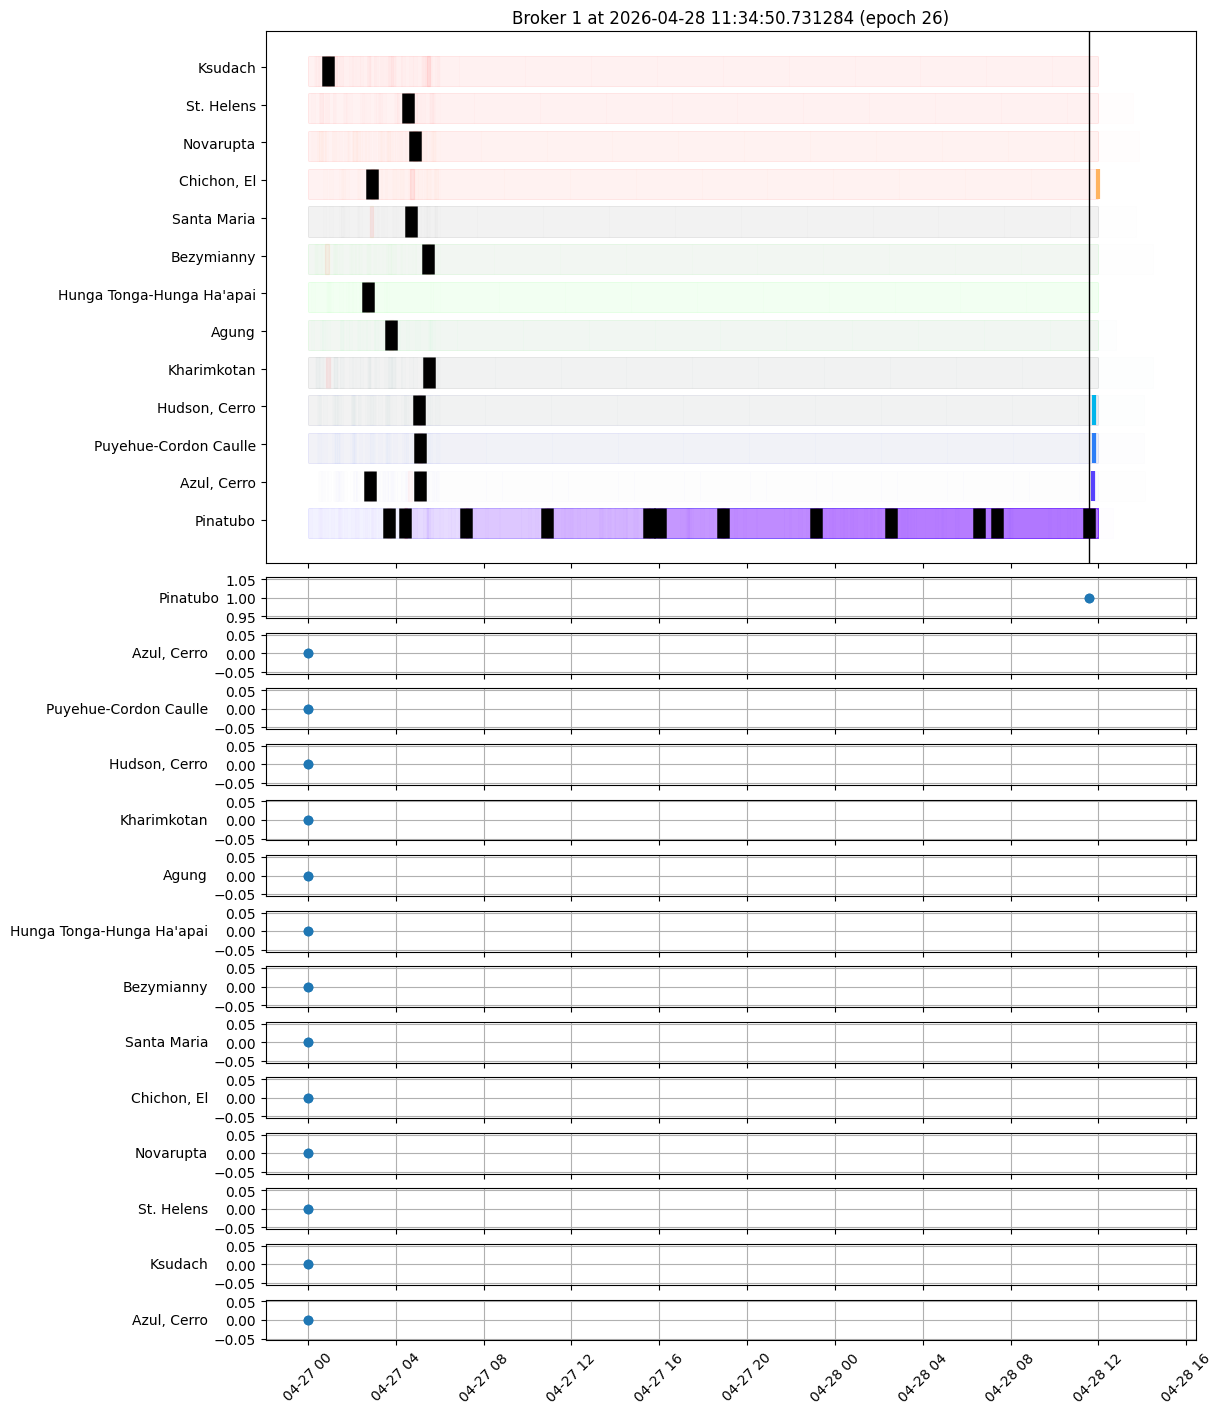

In [30]:
retcode = 1
while (retcode !=0):
    retcode = world_with_brokers.tick(print_forbidden_prefixes=["Downlink", "End of downlink", "Unlock uplink", "Unlock satellite after obs"])

In [31]:
save_prefix = "media/volcanos_v5"

In [32]:
# with open(f"{save_prefix}_chronicle.pkl",'wb') as file:
#     dill.dump(world_with_brokers.history, file)

In [33]:
retell_history(world_with_brokers)

Time: 2026-04-27 00:53:32.111923. Event: Event Obs, sat PELICAN-300B at 2026-04-27 00:53:32.111923
Observation: sat PELICAN-300B and opportunity Observation  at 2026-04-27 00:53:32.111923 by PELICAN-300B with InstrumentType.RGB. Look angle 299.24071035497275 | 66.06302869378734 az/dec deg, zenith angle 38.63290096086589 deg, range 488.3864232754038 km, duration 0:01:00
Time: 2026-04-27 00:53:32.111923. Event: Event ISL Downlink from sat PELICAN-300B at 2026-04-27 00:53:32.111923
Communication: station ISL to sat PELICAN-300B during pass ISL
Time: 2026-04-27 00:54:32.111923. Event: Event Unlock satellite after obs, sat PELICAN-300B at 2026-04-27 00:54:32.111923
Time: 2026-04-27 00:59:57.450104. Event: Event Check timeout Ksudach at 2026-04-27 00:59:57.450104
Time: 2026-04-27 02:43:03.168065. Event: Event Obs, sat SKYSAT-C11 at 2026-04-27 02:43:03.168065
Observation: sat SKYSAT-C11 and opportunity Observation  at 2026-04-27 02:43:03.168065 by SKYSAT-C11 with InstrumentType.RGB. Look angl

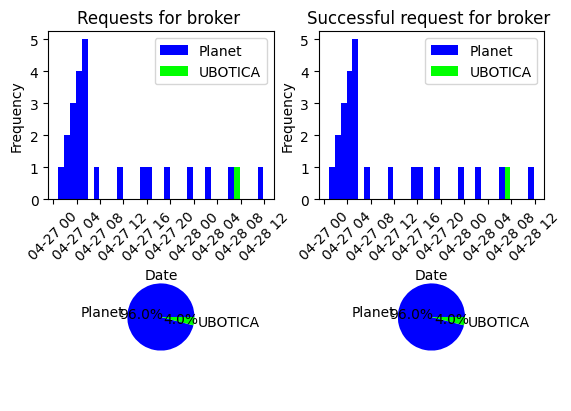

In [34]:
fig, stats_axes = plt.subplots(2,2)

stats_axes_linear = [stats_axes[0][0], stats_axes[1][0], stats_axes[0][1], stats_axes[1][1]]

plot_request_statistics(broker._requests, axes=stats_axes_linear, constellation_colors=constcolors)

# request_statistics(broker._requests)

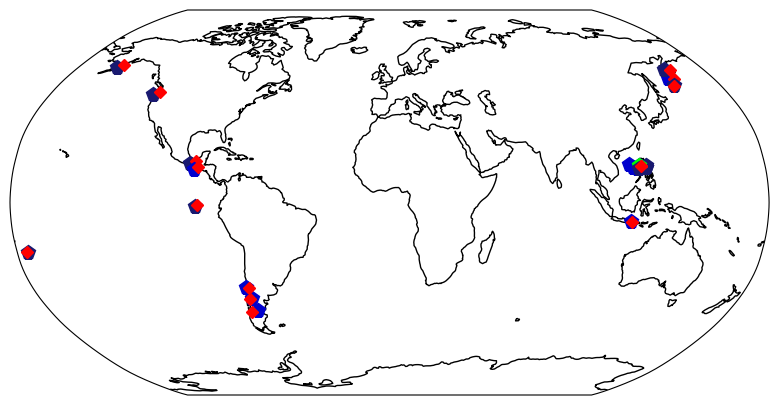

In [35]:
figglobal = plt.figure(figsize=(10,5))
ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

_plot_offset_deg = 10

# mapcenter = Location(lon_deg=3.8, lat_deg=60, alt_km=0)

# axes_extents = (float(mapcenter.lon_deg)-_plot_offset_deg, float(mapcenter.lon_deg)+_plot_offset_deg, float(mapcenter.lat_deg)-_plot_offset_deg, float(mapcenter.lat_deg)+_plot_offset_deg)
# ax.set_extent(axes_extents, crs=ccrs.PlateCarree())

for _chronicle in world_with_brokers.history:
    if type(_chronicle['event']) in [ObservationEvent]:
        _ax = plot_event(
            _chronicle,
            world_with_brokers,
            ax=ax,
            satellite_colors=satcolor,
            satellite_markers=satmarker,
            constellation_colors=constcolors,
            plot_time=False,
            plot_phenomena=False,
            plot_satellite_tracks=False,
            plot_ground_stations=False,
            plot_observation_gaze=True,
            plot_observation_target=True,
            plot_satellites=True
            )
        
# ax.plot([pos.lon_deg for pos in phenomena_rotterdam],[pos.lat_deg for pos in phenomena_rotterdam],transform=ccrs.Geodetic(), label="TOI trajectory (Rotterdam)")
# ax.plot([pos.lon_deg for pos in phenomena_gothenburg],[pos.lat_deg for pos in phenomena_gothenburg],transform=ccrs.Geodetic(), label="TOI trajectory (Gothenburg)")
# plt.savefig("media/MSA2_observations_2ships_v2_sigmahdg_{}_sigmav_{}.png".format(heading_variance, speed_variance),bbox_inches='tight')
# plt.savefig("media/MSA2_observations_2ships_v2_sigmahdg_{}_sigmav_{}.pdf".format(heading_variance, speed_variance),bbox_inches='tight')


In [36]:
print("There were {} observations".format(len([_e for _e in world_with_brokers.history if (type(_e['event']) in [ObservationEvent,])])))

There were 25 observations
